## Segmentation RFM 

In [1]:
%pip install pytest

Note: you may need to restart the kernel to use updated packages.


In [2]:
import duckdb
import os
from pathlib import Path
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

### Connexion à la DB / Import des Data


In [3]:
# Store database at project root
DB_NAME = Path("/home/c-enjalbert/Documents/Github/MSPR/bloc_2/amazing/amazing.duckdb") 
# Go up one level from current directory to get to project root
data_folder = Path("..") / "data"
# For absolute certainty, you could use the absolute path
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")
con = duckdb.connect(str(DB_NAME))

In [4]:
# 2. Query to list all tables in the database
# DuckDB specific way to list tables
tables_info = con.sql("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_name
""").df()

print(f"Found {len(tables_info)} tables in the database:\n")

if len(tables_info) > 0:
    for i, table_name in enumerate(tables_info['table_name']):
        print(f"{i+1}. {table_name}")
else:
    print("No tables found in the database.")

Found 4 tables in the database:

1. all_events
2. loaded_files
3. user_events
4. user_segments_kmeans


In [5]:
# 5. Alternative way to show all tables
print("List of all tables using DuckDB's connections.tables():")
con.sql("SHOW TABLES").show()

List of all tables using DuckDB's connections.tables():
┌──────────────────────┐
│         name         │
│       varchar        │
├──────────────────────┤
│ all_events           │
│ loaded_files         │
│ user_events          │
│ user_segments_kmeans │
└──────────────────────┘



In [6]:
# Show count of records in user_segments
user_segments_data = con.sql("""
    SELECT *
    FROM user_events
    ORDER BY RANDOM()
    LIMIT 10000
""")
user_segments_data.show()

# Examine the loaded_files table
print("\nContents of loaded_files table:")
loaded_files_data = con.sql("""
    SELECT * FROM loaded_files
""")
loaded_files_data.show()


┌───────────┬──────────────┬─────────────┬─────────────────┬─────────────────────────┬────────────────────┬────────────────────┬─────────────────────┬──────────────────────┬──────────────────────┬───────────────────────┐
│  user_id  │ total_events │ total_views │ total_purchases │ avg_time_between_events │    total_spent     │     avg_basket     │   last_event_time   │   conversion_rate    │    purchase_ratio    │ days_since_last_event │
│  varchar  │    int64     │   double    │     double      │         double          │       double       │       double       │      timestamp      │        double        │        double        │         int64         │
├───────────┼──────────────┼─────────────┼─────────────────┼─────────────────────────┼────────────────────┼────────────────────┼─────────────────────┼──────────────────────┼──────────────────────┼───────────────────────┤
│ 558727338 │           18 │        16.0 │             1.0 │      317531.64705882355 │             450.69 │         

In [7]:
user_segments_df_tmspt = user_segments_data.df()

In [8]:
user_segments_df = user_segments_data.df()

In [9]:
user_segments_df_tmspt.columns

Index(['user_id', 'total_events', 'total_views', 'total_purchases',
       'avg_time_between_events', 'total_spent', 'avg_basket',
       'last_event_time', 'conversion_rate', 'purchase_ratio',
       'days_since_last_event'],
      dtype='object')

In [10]:
# Check basic statistics and missing values
print("Basic statistics of the dataset:")
print(f"Number of users: {len(user_segments_df_tmspt)}")
print(f"Number of columns: {len(user_segments_df_tmspt.columns)}")
print("\nMissing values per column:")
print(user_segments_df_tmspt.isna().sum())

# Generate descriptive statistics
print("\nDescriptive statistics:")
user_segments_df_tmspt_stats = user_segments_df_tmspt.describe()
user_segments_df_tmspt_stats

Basic statistics of the dataset:
Number of users: 10000
Number of columns: 11

Missing values per column:
user_id                    0
total_events               0
total_views                0
total_purchases            0
avg_time_between_events    0
total_spent                0
avg_basket                 0
last_event_time            0
conversion_rate            0
purchase_ratio             0
days_since_last_event      0
dtype: int64

Descriptive statistics:


,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event
count,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000
mean,67.781200,63.162400,1.211900,2.085009e+05,363.086579,87.610288,2020-02-29 20:07:34.943300,0.027356,0.022771,31.046300
min,10.000000,3.000000,0.000000,2.105263e+00,0.000000,0.000000,2019-10-01 10:14:45,0.000000,0.000000,-30.000000
25%,16.000000,15.000000,0.000000,3.165769e+04,0.000000,0.000000,2020-01-21 02:39:20.750000,0.000000,0.000000,-19.000000
50%,30.000000,28.000000,0.000000,1.123763e+05,0.000000,0.000000,2020-03-15 08:19:57,0.000000,0.000000,16.000000
75%,69.000000,63.000000,1.000000,2.794712e+05,130.485000,83.089167,2020-04-20 16:49:57.500000,0.015873,0.015625,70.000000
max,4033.000000,3880.000000,218.000000,1.998062e+06,87962.690000,2007.520000,2020-04-30 23:44:10,1.250000,0.555556,182.000000
std,126.472937,120.308185,4.917847,2.634696e+05,1922.514522,203.467263,NaN,0.073530,0.054545,56.717929


In [11]:
user_segments_df_tmspt_stats["avg_time_between_events"]

count    1.000000e+04
mean     2.085009e+05
min      2.105263e+00
25%      3.165769e+04
50%      1.123763e+05
75%      2.794712e+05
max      1.998062e+06
std      2.634696e+05
Name: avg_time_between_events, dtype: float64

In [12]:
user_segments_df_tmspt_stats["days_since_last_event"]

count    10000.000000
mean        31.046300
min        -30.000000
25%        -19.000000
50%         16.000000
75%         70.000000
max        182.000000
std         56.717929
Name: days_since_last_event, dtype: float64

In [13]:
user_segments_df_tmspt['days_since_last_event']

0       -22
1       -28
2       176
3       156
4        20
       ... 
9995     92
9996    130
9997     -2
9998     94
9999    -21
Name: days_since_last_event, Length: 10000, dtype: int64

In [14]:
user_segments_df_tmspt

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event
0,621666961,25,25.0,0.0,177854.708333,0.00,0.0000,2020-04-23 15:43:28,0.000000,0.000000,-22
1,575336124,48,48.0,0.0,291141.829787,0.00,0.0000,2020-04-29 17:56:30,0.000000,0.000000,-28
2,557550064,16,16.0,0.0,80.733333,0.00,0.0000,2019-10-07 02:21:09,0.000000,0.000000,176
3,513601305,64,61.0,2.0,24677.555556,449.40,224.7000,2019-10-27 06:39:36,0.032787,0.031746,156
4,612100896,146,137.0,1.0,18890.255172,346.73,346.7300,2020-03-11 07:27:02,0.007299,0.007246,20
...,...,...,...,...,...,...,...,...,...,...,...
9995,532087235,35,22.0,4.0,27748.352941,6726.61,1681.6525,2019-12-30 05:31:58,0.181818,0.153846,92
9996,523298443,34,34.0,0.0,58520.121212,0.00,0.0000,2019-11-22 11:07:39,0.000000,0.000000,130
9997,529119936,16,15.0,0.0,907377.333333,0.00,0.0000,2020-04-03 18:04:35,0.000000,0.000000,-2
9998,530769039,122,122.0,0.0,31359.710744,0.00,0.0000,2019-12-28 16:26:14,0.000000,0.000000,94


In [15]:
print(user_segments_df_tmspt['last_event_time'].iloc[0:5])
print(type(user_segments_df_tmspt['last_event_time'].iloc[0]))

0   2020-04-23 15:43:28
1   2020-04-29 17:56:30
2   2019-10-07 02:21:09
3   2019-10-27 06:39:36
4   2020-03-11 07:27:02
Name: last_event_time, dtype: datetime64[us]
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [16]:
# Conversion des jours en mois (approximation: 30 jours = 1 mois)
user_segments_df_tmspt['months_since_last_event'] = user_segments_df_tmspt['days_since_last_event'] / 30

In [17]:
def perform_rfm_analysis(df, 
                        r_column='months_since_last_event',
                        r_thresholds=[1, 5],
                        r_scores=[2, 1, 0],
                        f_column='total_purchases',
                        f_thresholds=[2, 10],
                        f_scores=[0, 1, 2],
                        m_column='total_spent',
                        m_thresholds=[20, 50],
                        m_scores=[0, 1, 2],
                        segment_thresholds=[0, 2, 3, 4, 6],
                        segment_names=['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions'],
                        days_to_months=30,
                        visualize=True):
    """
    Réalise une analyse RFM complète avec des seuils et critères personnalisables
    
    Args:
        df (pd.DataFrame): DataFrame contenant les données client
        r_column (str): Nom de la colonne pour la récence
        r_thresholds (list): Seuils pour la récence (ex: [1, 5] pour <1 mois, 1-5 mois, >5 mois)
        r_scores (list): Scores à attribuer pour chaque segment de récence
        f_column (str): Nom de la colonne pour la fréquence
        f_thresholds (list): Seuils pour la fréquence (ex: [2, 10] pour <2, 2-10, >10)
        f_scores (list): Scores à attribuer pour chaque segment de fréquence
        m_column (str): Nom de la colonne pour le montant
        m_thresholds (list): Seuils pour le montant (ex: [20, 50] pour <20€, 20-50€, >50€)
        m_scores (list): Scores à attribuer pour chaque segment de montant
        segment_thresholds (list): Seuils pour les segments client basés sur le score RFM total
        segment_names (list): Noms des segments clients
        days_to_months (int): Facteur de conversion jours en mois (si applicable)
        visualize (bool): Afficher les graphiques
    
    Returns:
        pd.DataFrame: DataFrame original avec les scores et segments RFM ajoutés
    """
    # Créer une copie du dataframe pour ne pas modifier l'original
    df_rfm = df.copy()
    
    # Convertir days_since_last_event en months_since_last_event si nécessaire
    if r_column == 'months_since_last_event' and 'days_since_last_event' in df_rfm.columns and 'months_since_last_event' not in df_rfm.columns:
        df_rfm['months_since_last_event'] = df_rfm['days_since_last_event'] / days_to_months
    
    # Fonction pour assigner les scores selon les critères et seuils
    def assign_score(value, thresholds, scores):
        if len(thresholds) + 1 != len(scores):
            raise ValueError("Le nombre de scores doit être égal au nombre de seuils + 1")
        
        # Vérifier dans quelle plage se trouve la valeur
        for i, threshold in enumerate(thresholds):
            if value < threshold:
                return scores[i]
        
        # Si la valeur est supérieure à tous les seuils, retourner le dernier score
        return scores[-1]
    
    # Appliquer les fonctions de score
    df_rfm['R_score'] = df_rfm[r_column].apply(lambda x: assign_score(x, r_thresholds, r_scores))
    df_rfm['F_score'] = df_rfm[f_column].apply(lambda x: assign_score(x, f_thresholds, f_scores))
    df_rfm['M_score'] = df_rfm[m_column].apply(lambda x: assign_score(x, m_thresholds, m_scores))
    
    # Créer un score RFM combiné (comme une chaîne de caractères)
    df_rfm['RFM_segment'] = df_rfm['R_score'].astype(str) + \
                           df_rfm['F_score'].astype(str) + \
                           df_rfm['M_score'].astype(str)
    
    # Calculer le score RFM total
    df_rfm['RFM_score'] = df_rfm['R_score'] + df_rfm['F_score'] + df_rfm['M_score']
    
    # Fonction pour attribuer un segment en fonction du score RFM total
    def assign_segment(score, thresholds, names):
        if len(thresholds) != len(names):
            raise ValueError("Le nombre de noms de segments doit être égal au nombre de seuils")
            
        for i in range(len(thresholds)-1):
            if thresholds[i] <= score < thresholds[i+1]:
                return names[i]
                
        return names[-1]  # Dernier segment si score >= dernier seuil
    
    # Attribuer les segments
    df_rfm['segment'] = df_rfm['RFM_score'].apply(lambda x: assign_segment(x, segment_thresholds, segment_names))
    
    # Afficher les résultats
    print("RFM Analysis Completed")
    print(f"Total clients segmentés: {len(df_rfm)}")
    
    # Afficher la distribution des scores individuels
    print("\nDistribution des scores R:")
    r_dist = df_rfm['R_score'].value_counts().sort_index()
    print(r_dist)
    
    print("\nDistribution des scores F:")
    f_dist = df_rfm['F_score'].value_counts().sort_index()
    print(f_dist)
    
    print("\nDistribution des scores M:")
    m_dist = df_rfm['M_score'].value_counts().sort_index()
    print(m_dist)
    
    print("\nDistribution des segments RFM:")
    print(df_rfm['RFM_segment'].value_counts())
    
    # Afficher les critères RFM utilisés
    print("\n--- CRITÈRES RFM UTILISÉS ---\n")
    
    # Récence
    print(f"RÉCENCE ({r_column}):")
    if len(r_thresholds) == 2:
        print(f"Score {r_scores[0]}: moins de {r_thresholds[0]}")
        print(f"Score {r_scores[1]}: entre {r_thresholds[0]} et {r_thresholds[1]}")
        print(f"Score {r_scores[2]}: plus de {r_thresholds[1]}")
    else:
        for i in range(len(r_scores)):
            if i == 0:
                print(f"Score {r_scores[i]}: moins de {r_thresholds[i]}")
            elif i == len(r_scores) - 1:
                print(f"Score {r_scores[i]}: plus de {r_thresholds[i-1]}")
            else:
                print(f"Score {r_scores[i]}: entre {r_thresholds[i-1]} et {r_thresholds[i]}")
    
    # Fréquence
    print(f"\nFRÉQUENCE ({f_column}):")
    if len(f_thresholds) == 2:
        print(f"Score {f_scores[0]}: moins de {f_thresholds[0]}")
        print(f"Score {f_scores[1]}: entre {f_thresholds[0]} et {f_thresholds[1]}")
        print(f"Score {f_scores[2]}: plus de {f_thresholds[1]}")
    else:
        for i in range(len(f_scores)):
            if i == 0:
                print(f"Score {f_scores[i]}: moins de {f_thresholds[i]}")
            elif i == len(f_scores) - 1:
                print(f"Score {f_scores[i]}: plus de {f_thresholds[i-1]}")
            else:
                print(f"Score {f_scores[i]}: entre {f_thresholds[i-1]} et {f_thresholds[i]}")
    
    # Montant
    print(f"\nMONTANT ({m_column}):")
    if len(m_thresholds) == 2:
        print(f"Score {m_scores[0]}: moins de {m_thresholds[0]}€")
        print(f"Score {m_scores[1]}: entre {m_thresholds[0]}€ et {m_thresholds[1]}€")
        print(f"Score {m_scores[2]}: plus de {m_thresholds[1]}€")
    else:
        for i in range(len(m_scores)):
            if i == 0:
                print(f"Score {m_scores[i]}: moins de {m_thresholds[i]}€")
            elif i == len(m_scores) - 1:
                print(f"Score {m_scores[i]}: plus de {m_thresholds[i-1]}€")
            else:
                print(f"Score {m_scores[i]}: entre {m_thresholds[i-1]}€ et {m_thresholds[i]}€")
    
    # Distribution des segments de clients
    print("\nDistribution des segments de clients:")
    segment_counts = df_rfm['segment'].value_counts()
    for segment, count in segment_counts.items():
        print(f"{segment}: {count} clients ({count/len(df_rfm)*100:.1f}%)")
    
    # Visualisation
    if visualize:
        # Visualisation des segments
        plt.figure(figsize=(10, 6))
        sns.countplot(x='segment', data=df_rfm, order=segment_counts.index)
        plt.title('Distribution des Segments Clients')
        plt.xlabel('Segment')
        plt.ylabel('Nombre de Clients')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Visualisation des scores R, F, M
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        sns.countplot(x='R_score', data=df_rfm, ax=axes[0])
        axes[0].set_title('Distribution des Scores R')
        axes[0].set_xlabel('Score R')
        axes[0].set_ylabel('Nombre de Clients')
        
        sns.countplot(x='F_score', data=df_rfm, ax=axes[1])
        axes[1].set_title('Distribution des Scores F')
        axes[1].set_xlabel('Score F')
        axes[1].set_ylabel('Nombre de Clients')
        
        sns.countplot(x='M_score', data=df_rfm, ax=axes[2])
        axes[2].set_title('Distribution des Scores M')
        axes[2].set_xlabel('Score M')
        axes[2].set_ylabel('Nombre de Clients')
        
        plt.tight_layout()
        plt.show()
    
    # Générer un tableau récapitulatif avec les caractéristiques de chaque segment
    print("\nCaractéristiques moyennes par segment:")
    segment_stats = df_rfm.groupby('segment').agg({
        r_column: 'mean',
        f_column: 'mean',
        m_column: 'mean',
        'R_score': 'mean',
        'F_score': 'mean',
        'M_score': 'mean',
        'RFM_score': 'mean',
        df_rfm.columns[0]: 'count'  # Utiliser la première colonne pour le comptage
    }).rename(columns={df_rfm.columns[0]: 'count'}).sort_values(by='RFM_score', ascending=False)
    
    segment_stats = segment_stats.round(2)
    display(segment_stats)
    
    return df_rfm



RFM Analysis Completed
Total clients segmentés: 10000

Distribution des scores R:
R_score
0     399
1    3702
2    5899
Name: count, dtype: int64

Distribution des scores F:
F_score
0    8129
1    1656
2     215
Name: count, dtype: int64

Distribution des scores M:
M_score
0    6863
1     219
2    2918
Name: count, dtype: int64

Distribution des segments RFM:
RFM_segment
200    3897
100    2675
212    1052
202     642
112     518
102     385
000     281
222     145
201     132
122      64
002      57
101      54
012      49
211      23
210       8
001       6
022       6
111       4
110       2
Name: count, dtype: int64

--- CRITÈRES RFM UTILISÉS ---

RÉCENCE (months_since_last_event):
Score 2: moins de 1
Score 1: entre 1 et 5
Score 0: plus de 5

FRÉQUENCE (total_purchases):
Score 0: moins de 2
Score 1: entre 2 et 10
Score 2: plus de 10

MONTANT (total_spent):
Score 0: moins de 20€
Score 1: entre 20€ et 50€
Score 2: plus de 50€

Distribution des segments de clients:
Clients Perdus: 697

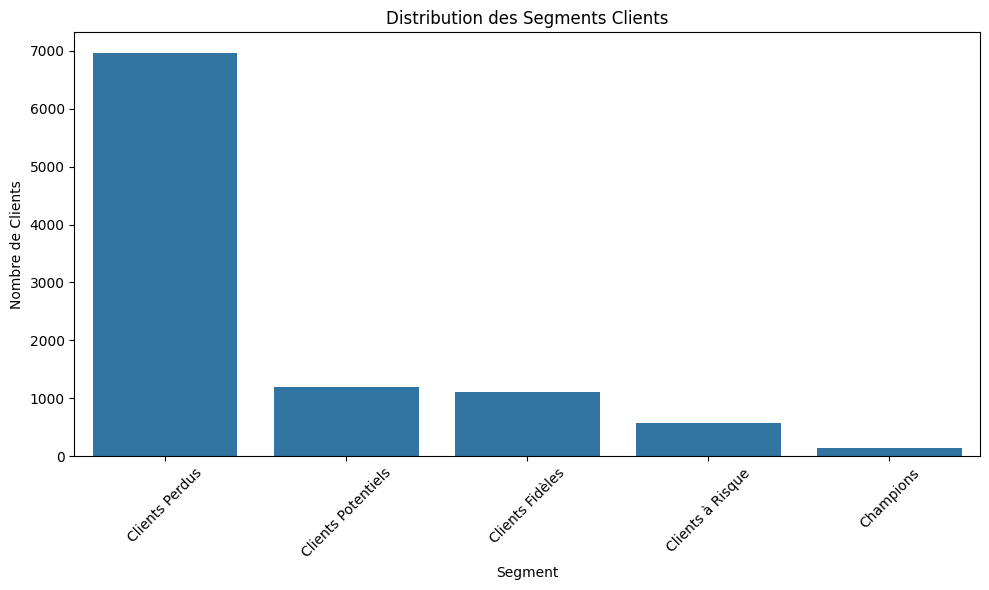

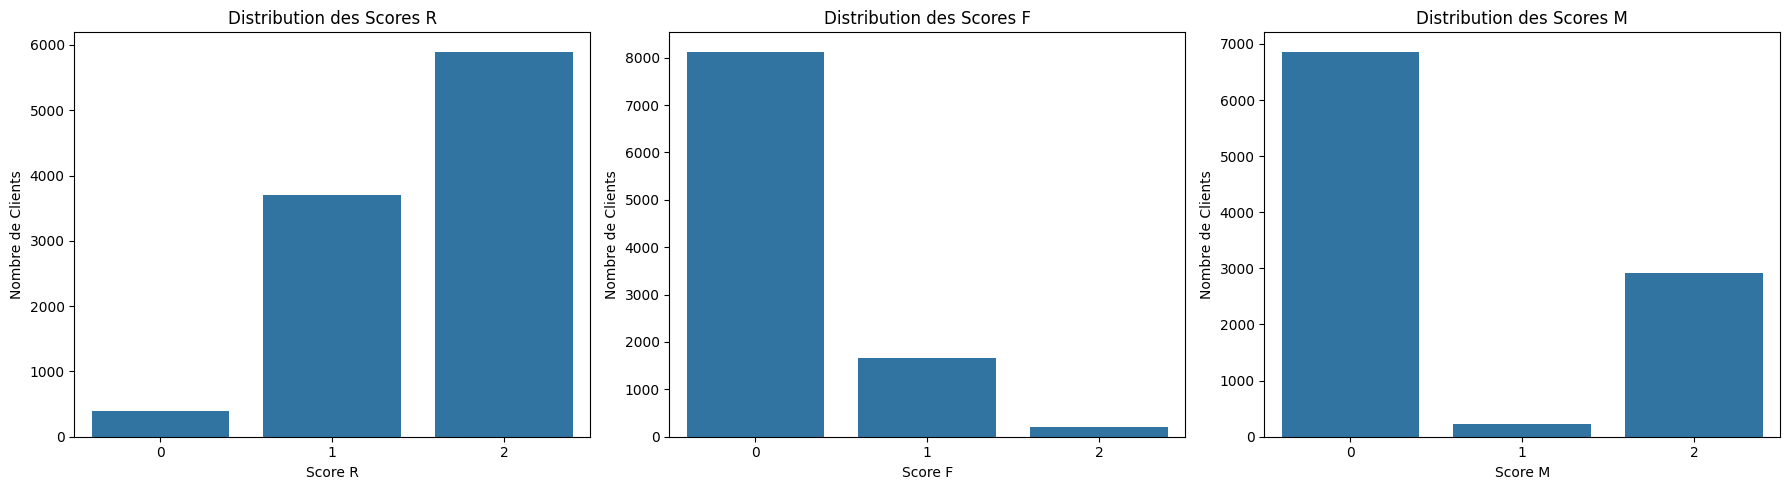


Caractéristiques moyennes par segment:


,months_since_last_event,total_purchases,total_spent,R_score,F_score,M_score,RFM_score,count
segment,,,,,,,,
Champions,-0.34,22.50,6693.18,2.00,2.00,2.00,6.00,145
Clients Fidèles,-0.21,4.77,1466.50,1.94,1.06,2.00,5.00,1116
Clients Potentiels,0.97,2.22,685.20,1.55,0.47,1.98,4.00,1189
Clients à Risque,2.23,1.20,323.48,1.16,0.11,1.74,3.00,578
Clients Perdus,1.18,0.03,3.17,1.51,0.00,0.02,1.53,6972


"\nrfm_custom = perform_rfm_analysis(\n    user_segments_df,\n    r_column='months_since_last_event',\n    r_thresholds=[0.5, 2, 6],  # 4 segments de récence\n    r_scores=[3, 2, 1, 0],\n    f_column='total_purchases',\n    f_thresholds=[1, 5, 15],  # 4 segments de fréquence\n    f_scores=[0, 1, 2, 3],\n    m_column='total_spent',\n    m_thresholds=[10, 30, 80],  # 4 segments de montant\n    m_scores=[0, 1, 2, 3],\n    segment_thresholds=[0, 2, 4, 6, 8],  # Seuils de segmentation personnalisés\n    segment_names=['Inactifs', 'À Réactiver', 'Réguliers', 'Fidèles', 'VIP']\n)\n"

In [18]:

user_segments_complete = perform_rfm_analysis(
    user_segments_df_tmspt,
    r_column='months_since_last_event',
    r_thresholds=[1, 5],
    r_scores=[2, 1, 0],
    f_column='total_purchases',
    f_thresholds=[2, 10],
    f_scores=[0, 1, 2],
    m_column='total_spent',
    m_thresholds=[20, 50],
    m_scores=[0, 1, 2],
    segment_thresholds=[0, 3, 4, 5, 6],
    segment_names=['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']
)

# Pour utiliser avec un autre jeu de critères, il suffit d'appeler la fonction 
# avec des paramètres différents, par exemple:
"""
rfm_custom = perform_rfm_analysis(
    user_segments_df,
    r_column='months_since_last_event',
    r_thresholds=[0.5, 2, 6],  # 4 segments de récence
    r_scores=[3, 2, 1, 0],
    f_column='total_purchases',
    f_thresholds=[1, 5, 15],  # 4 segments de fréquence
    f_scores=[0, 1, 2, 3],
    m_column='total_spent',
    m_thresholds=[10, 30, 80],  # 4 segments de montant
    m_scores=[0, 1, 2, 3],
    segment_thresholds=[0, 2, 4, 6, 8],  # Seuils de segmentation personnalisés
    segment_names=['Inactifs', 'À Réactiver', 'Réguliers', 'Fidèles', 'VIP']
)
"""

In [19]:
user_segments_complete

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event,months_since_last_event,R_score,F_score,M_score,RFM_segment,RFM_score,segment
0,621666961,25,25.0,0.0,177854.708333,0.00,0.0000,2020-04-23 15:43:28,0.000000,0.000000,-22,-0.733333,2,0,0,200,2,Clients Perdus
1,575336124,48,48.0,0.0,291141.829787,0.00,0.0000,2020-04-29 17:56:30,0.000000,0.000000,-28,-0.933333,2,0,0,200,2,Clients Perdus
2,557550064,16,16.0,0.0,80.733333,0.00,0.0000,2019-10-07 02:21:09,0.000000,0.000000,176,5.866667,0,0,0,000,0,Clients Perdus
3,513601305,64,61.0,2.0,24677.555556,449.40,224.7000,2019-10-27 06:39:36,0.032787,0.031746,156,5.200000,0,1,2,012,3,Clients à Risque
4,612100896,146,137.0,1.0,18890.255172,346.73,346.7300,2020-03-11 07:27:02,0.007299,0.007246,20,0.666667,2,0,2,202,4,Clients Potentiels
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,532087235,35,22.0,4.0,27748.352941,6726.61,1681.6525,2019-12-30 05:31:58,0.181818,0.153846,92,3.066667,1,1,2,112,4,Clients Potentiels
9996,523298443,34,34.0,0.0,58520.121212,0.00,0.0000,2019-11-22 11:07:39,0.000000,0.000000,130,4.333333,1,0,0,100,1,Clients Perdus
9997,529119936,16,15.0,0.0,907377.333333,0.00,0.0000,2020-04-03 18:04:35,0.000000,0.000000,-2,-0.066667,2,0,0,200,2,Clients Perdus
9998,530769039,122,122.0,0.0,31359.710744,0.00,0.0000,2019-12-28 16:26:14,0.000000,0.000000,94,3.133333,1,0,0,100,1,Clients Perdus


In [20]:
# Analyse des paniers moyens (avg_basket)
print("\n--- ANALYSE DES PANIERS MOYENS ---")

# Compter les paniers avec avg_basket = 0
zero_baskets = len(user_segments_complete[user_segments_complete['avg_basket'] == 0])
print(f"Nombre de clients avec panier moyen = 0: {zero_baskets} ({zero_baskets/len(user_segments_complete)*100:.1f}%)")

# Compter les paniers avec avg_basket > 0
non_zero_baskets = len(user_segments_complete[user_segments_complete['avg_basket'] > 0])
print(f"Nombre de clients avec panier moyen > 0: {non_zero_baskets} ({non_zero_baskets/len(user_segments_complete)*100:.1f}%)")




--- ANALYSE DES PANIERS MOYENS ---
Nombre de clients avec panier moyen = 0: 6776 (67.8%)
Nombre de clients avec panier moyen > 0: 3224 (32.2%)


In [21]:
# Analyse de la récence (months_since_last_event)
print("\n--- Analyse de months_since_last_event ---")

moins_1_mois = len(user_segments_complete[user_segments_complete['months_since_last_event'] < 1])
entre_1_5_mois = len(user_segments_complete[(user_segments_complete['months_since_last_event'] >= 1) & (user_segments_complete['months_since_last_event'] <= 5)])
plus_5_mois = len(user_segments_complete[user_segments_complete['months_since_last_event'] > 5])

total = len(user_segments_complete)
print(f"Moins de 1 mois depuis le dernier événement : {moins_1_mois} ({moins_1_mois/total*100:.1f}%)")
print(f"Entre 1 et 5 mois depuis le dernier événement : {entre_1_5_mois} ({entre_1_5_mois/total*100:.1f}%)")
print(f"Plus de 5 mois depuis le dernier événement : {plus_5_mois} ({plus_5_mois/total*100:.1f}%)")




--- Analyse de months_since_last_event ---
Moins de 1 mois depuis le dernier événement : 5899 (59.0%)
Entre 1 et 5 mois depuis le dernier événement : 3717 (37.2%)
Plus de 5 mois depuis le dernier événement : 384 (3.8%)


In [22]:
user_segments_df

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event
0,584449758,21,21.0,0.0,47604.100000,0.00,0.000000,2019-12-21 20:31:27,0.000000,0.000000,101
1,611291905,225,223.0,0.0,28759.495536,0.00,0.000000,2020-04-21 06:00:50,0.000000,0.000000,-20
2,543275591,18,16.0,1.0,5421.529412,70.53,70.530000,2019-10-13 10:31:22,0.062500,0.058824,170
3,519052691,81,75.0,1.0,16980.087500,926.32,926.320000,2020-04-18 06:09:12,0.013333,0.013158,-17
4,558110572,57,57.0,0.0,263745.285714,0.00,0.000000,2020-03-27 13:24:24,0.000000,0.000000,4
...,...,...,...,...,...,...,...,...,...,...,...
9995,563576095,51,51.0,0.0,259735.220000,0.00,0.000000,2020-04-05 15:35:47,0.000000,0.000000,-4
9996,513409431,154,141.0,3.0,107351.849673,179.59,59.863333,2020-04-30 08:37:41,0.021277,0.020833,-29
9997,605313669,27,27.0,0.0,30511.884615,0.00,0.000000,2020-02-02 09:21:45,0.000000,0.000000,58
9998,515894246,69,67.0,0.0,32235.294118,0.00,0.000000,2020-03-04 15:36:15,0.000000,0.000000,27


In [23]:
user_segments_complete

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event,months_since_last_event,R_score,F_score,M_score,RFM_segment,RFM_score,segment
0,621666961,25,25.0,0.0,177854.708333,0.00,0.0000,2020-04-23 15:43:28,0.000000,0.000000,-22,-0.733333,2,0,0,200,2,Clients Perdus
1,575336124,48,48.0,0.0,291141.829787,0.00,0.0000,2020-04-29 17:56:30,0.000000,0.000000,-28,-0.933333,2,0,0,200,2,Clients Perdus
2,557550064,16,16.0,0.0,80.733333,0.00,0.0000,2019-10-07 02:21:09,0.000000,0.000000,176,5.866667,0,0,0,000,0,Clients Perdus
3,513601305,64,61.0,2.0,24677.555556,449.40,224.7000,2019-10-27 06:39:36,0.032787,0.031746,156,5.200000,0,1,2,012,3,Clients à Risque
4,612100896,146,137.0,1.0,18890.255172,346.73,346.7300,2020-03-11 07:27:02,0.007299,0.007246,20,0.666667,2,0,2,202,4,Clients Potentiels
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,532087235,35,22.0,4.0,27748.352941,6726.61,1681.6525,2019-12-30 05:31:58,0.181818,0.153846,92,3.066667,1,1,2,112,4,Clients Potentiels
9996,523298443,34,34.0,0.0,58520.121212,0.00,0.0000,2019-11-22 11:07:39,0.000000,0.000000,130,4.333333,1,0,0,100,1,Clients Perdus
9997,529119936,16,15.0,0.0,907377.333333,0.00,0.0000,2020-04-03 18:04:35,0.000000,0.000000,-2,-0.066667,2,0,0,200,2,Clients Perdus
9998,530769039,122,122.0,0.0,31359.710744,0.00,0.0000,2019-12-28 16:26:14,0.000000,0.000000,94,3.133333,1,0,0,100,1,Clients Perdus


In [24]:
X = user_segments_df.drop(columns=["last_event_time"])
X_rfm = user_segments_complete.drop(columns=["segment", "last_event_time", "RFM_segment"])

In [25]:
X

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,conversion_rate,purchase_ratio,days_since_last_event
0,584449758,21,21.0,0.0,47604.100000,0.00,0.000000,0.000000,0.000000,101
1,611291905,225,223.0,0.0,28759.495536,0.00,0.000000,0.000000,0.000000,-20
2,543275591,18,16.0,1.0,5421.529412,70.53,70.530000,0.062500,0.058824,170
3,519052691,81,75.0,1.0,16980.087500,926.32,926.320000,0.013333,0.013158,-17
4,558110572,57,57.0,0.0,263745.285714,0.00,0.000000,0.000000,0.000000,4
...,...,...,...,...,...,...,...,...,...,...
9995,563576095,51,51.0,0.0,259735.220000,0.00,0.000000,0.000000,0.000000,-4
9996,513409431,154,141.0,3.0,107351.849673,179.59,59.863333,0.021277,0.020833,-29
9997,605313669,27,27.0,0.0,30511.884615,0.00,0.000000,0.000000,0.000000,58
9998,515894246,69,67.0,0.0,32235.294118,0.00,0.000000,0.000000,0.000000,27


In [26]:
X_rfm

,user_id,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,conversion_rate,purchase_ratio,days_since_last_event,months_since_last_event,R_score,F_score,M_score,RFM_score
0,621666961,25,25.0,0.0,177854.708333,0.00,0.0000,0.000000,0.000000,-22,-0.733333,2,0,0,2
1,575336124,48,48.0,0.0,291141.829787,0.00,0.0000,0.000000,0.000000,-28,-0.933333,2,0,0,2
2,557550064,16,16.0,0.0,80.733333,0.00,0.0000,0.000000,0.000000,176,5.866667,0,0,0,0
3,513601305,64,61.0,2.0,24677.555556,449.40,224.7000,0.032787,0.031746,156,5.200000,0,1,2,3
4,612100896,146,137.0,1.0,18890.255172,346.73,346.7300,0.007299,0.007246,20,0.666667,2,0,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,532087235,35,22.0,4.0,27748.352941,6726.61,1681.6525,0.181818,0.153846,92,3.066667,1,1,2,4
9996,523298443,34,34.0,0.0,58520.121212,0.00,0.0000,0.000000,0.000000,130,4.333333,1,0,0,1
9997,529119936,16,15.0,0.0,907377.333333,0.00,0.0000,0.000000,0.000000,-2,-0.066667,2,0,0,2
9998,530769039,122,122.0,0.0,31359.710744,0.00,0.0000,0.000000,0.000000,94,3.133333,1,0,0,1


## Evaluation du Modèle sans RFM Score

Silhouette Coefficient
0.5824204867485618
Calinski–Harabasz Index
43256.116470538014
Davies–Bouldin Index
0.49581139376304406


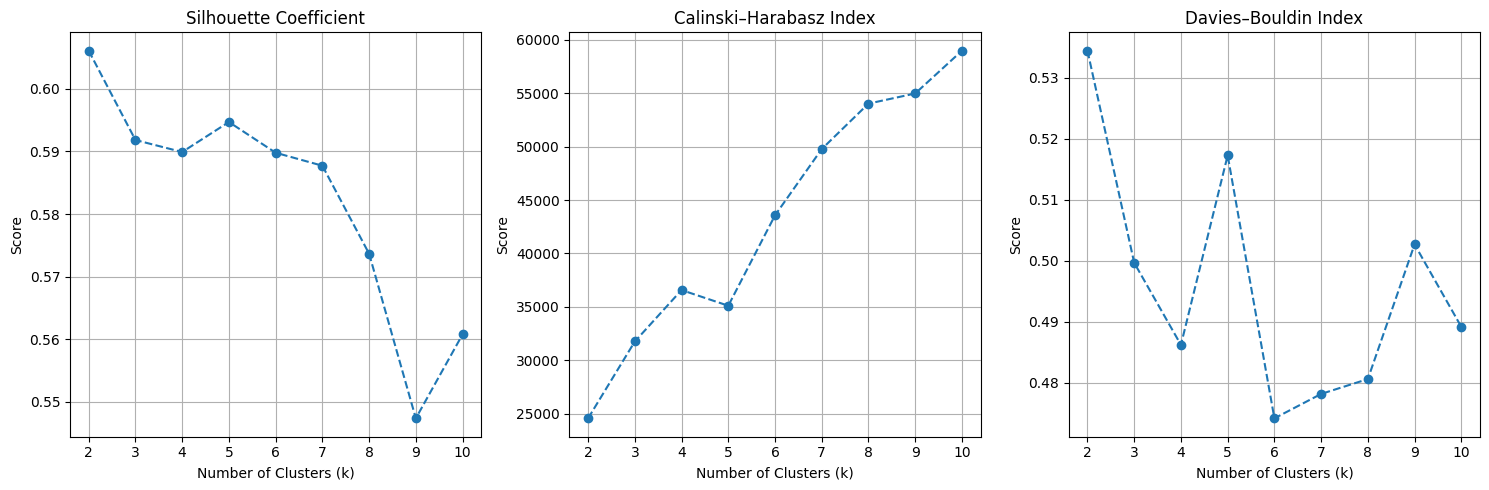

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

# Define the range of clusters to evaluate
ks = range(2, 11)

# Initialize lists to store the scores
silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []

# Evaluate clustering for each k
for k in ks:
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    labels = km.labels_
    
    # Compute the metrics
    silhouette_scores.append(silhouette_score(X, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X, labels))

# Plot the metrics
plt.figure(figsize=(15, 5))
print("Silhouette Coefficient")
print(np.mean(silhouette_scores))
# Silhouette Coefficient
plt.subplot(1, 3, 1)
plt.plot(ks, silhouette_scores, marker='o', linestyle='--')
plt.title("Silhouette Coefficient")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)
print("Calinski–Harabasz Index")
print(np.mean(calinski_harabasz_scores))
# Calinski–Harabasz Index
plt.subplot(1, 3, 2)
plt.plot(ks, calinski_harabasz_scores, marker='o', linestyle='--')
plt.title("Calinski–Harabasz Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)
print("Davies–Bouldin Index")
print(np.mean(davies_bouldin_scores))
plt.subplot(1, 3, 3)
plt.plot(ks, davies_bouldin_scores, marker='o', linestyle='--')
plt.title("Davies–Bouldin Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

plt.tight_layout()
plt.show()

## Evaluation du Modèle avec RFM Score

Silhouette Coefficient
0.5913934821471017
Calinski–Harabasz Index
50831.889698749714
Davies–Bouldin Index
0.4922637845485518


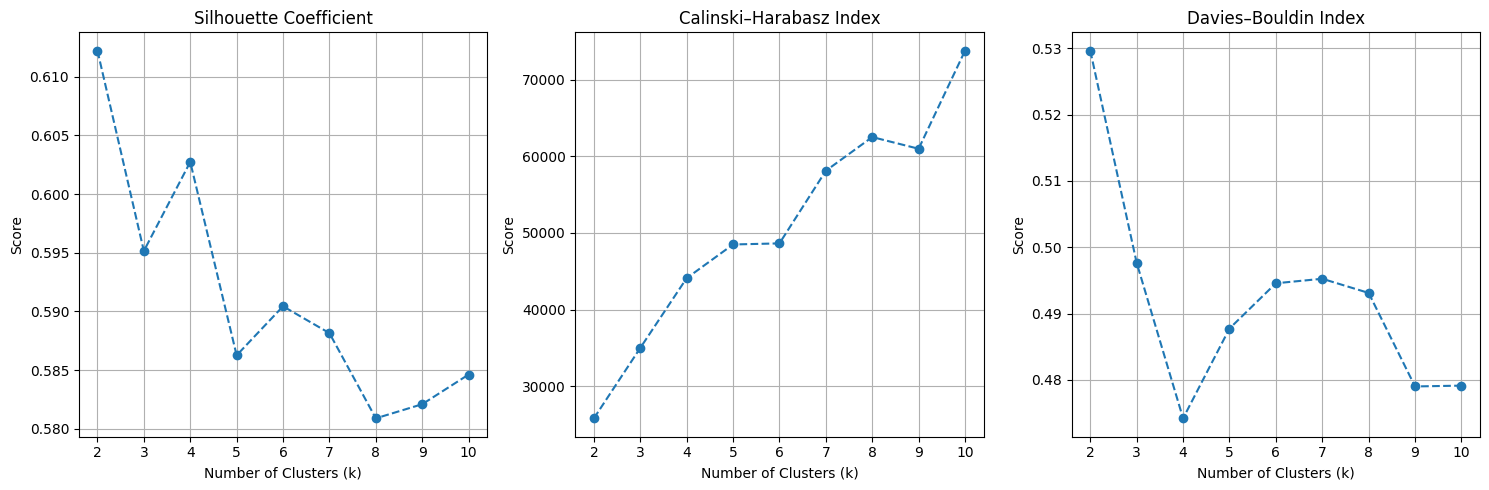

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

# Define the range of clusters to evaluate
ks = range(2, 11)

# Initialize lists to store the scores
silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []

# Evaluate clustering for each k
for k in ks:
    km2 = KMeans(n_clusters=k, random_state=42).fit(X_rfm)
    labels = km2.labels_
    
    # Compute the metrics
    silhouette_scores.append(silhouette_score(X_rfm, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_rfm, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_rfm, labels))

# Plot the metrics
plt.figure(figsize=(15, 5))
print("Silhouette Coefficient")
print(np.mean(silhouette_scores))

# Silhouette Coefficient
plt.subplot(1, 3, 1)
plt.plot(ks, silhouette_scores, marker='o', linestyle='--')
plt.title("Silhouette Coefficient")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)
print("Calinski–Harabasz Index")
print(np.mean(calinski_harabasz_scores))

# Calinski–Harabasz Index
plt.subplot(1, 3, 2)
plt.plot(ks, calinski_harabasz_scores, marker='o', linestyle='--')
plt.title("Calinski–Harabasz Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)
print("Davies–Bouldin Index")
print(np.mean(davies_bouldin_scores))

# Davies–Bouldin Index
plt.subplot(1, 3, 3)
plt.plot(ks, davies_bouldin_scores, marker='o', linestyle='--')
plt.title("Davies–Bouldin Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

plt.tight_layout()
plt.show()

## Evaluate Model Performance with Stratified K Fold (for better "purchase" and "basket" events )

In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


In [30]:
import pytest
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

def test_clustering_with_stratified_kfold():
    """
    Test clustering performance using StratifiedKFold cross-validation.
    
    For clustering (unsupervised learning), we need to:
    1. First perform clustering on the entire dataset
    2. Use the resulting labels as a "pseudo-target" for stratification
    3. Evaluate how consistent the clustering is across folds
    """
    # Load or create sample data (replace with actual data loading)
    # This is a simplified example - you'll need to adapt to your actual dataframe
    try:
        df = pd.read_csv('path_to_your_data.csv')  # Replace with your data loading
        X = df.drop(columns=["last_event_time"])  # Adjust columns as needed
    except:
        # Create dummy data for testing if file not found
        X = pd.DataFrame(np.random.rand(100, 5), 
                        columns=['total_purchases', 'total_spent', 'avg_basket', 
                                'days_since_last_event', 'avg_time_between_events'])
    
    # 1. First perform clustering on entire dataset to get "pseudo-labels"
    # Choose K based on your prior analysis
    k = 5  # Replace with your optimal K value
    kmeans = KMeans(n_clusters=k, random_state=42)
    pseudo_labels = kmeans.fit_predict(X)
    
    # 2. Use StratifiedKFold with these pseudo-labels
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Track metrics across folds
    silhouette_scores = []
    calinski_scores = []
    davies_bouldin_scores = []
    
    # 3. Cross-validate
    for train_idx, test_idx in skf.split(X, pseudo_labels):
        # Split data
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        
        # Scale features (recommended for KMeans)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train on fold
        fold_kmeans = KMeans(n_clusters=k, random_state=42)
        fold_kmeans.fit(X_train_scaled)
        
        # Predict on test set
        test_labels = fold_kmeans.predict(X_test_scaled)
        
        # Only calculate metrics if we have at least 2 clusters in test set
        unique_labels = np.unique(test_labels)
        if len(unique_labels) >= 2:
            # Calculate metrics
            silhouette_scores.append(silhouette_score(X_test_scaled, test_labels))
            calinski_scores.append(calinski_harabasz_score(X_test_scaled, test_labels))
            davies_bouldin_scores.append(davies_bouldin_score(X_test_scaled, test_labels))
    
    # 4. Assert that metrics are consistent and within expected range
    assert len(silhouette_scores) > 0, "No valid silhouette scores calculated"
    avg_silhouette = np.mean(silhouette_scores)
    avg_calinski = np.mean(calinski_scores)
    avg_davies_bouldin = np.mean(davies_bouldin_scores)
    
    # Print results for inspection
    print(f"Cross-validated metrics over {len(silhouette_scores)} folds:")
    print(f"Average Silhouette Score: {avg_silhouette:.4f}")
    print(f"Average Calinski-Harabasz Score: {avg_calinski:.4f}")
    print(f"Average Davies-Bouldin Score: {avg_davies_bouldin:.4f}")
    
    # Check if metrics are within reasonable range
    assert -1 <= avg_silhouette <= 1, f"Silhouette score {avg_silhouette} outside valid range [-1,1]"
    assert avg_calinski > 0, f"Calinski-Harabasz score {avg_calinski} should be positive"
    assert avg_davies_bouldin > 0, f"Davies-Bouldin score {avg_davies_bouldin} should be positive"

### Interprétation des métriques d'évaluation de clustering

Les trois métriques que vous utilisez (**Silhouette Coefficient**, **Calinski-Harabasz Index** et **Davies-Bouldin Index**) sont des indicateurs standard pour évaluer la qualité d'un clustering. Voici comment les interpréter :

---

#### 1. Coefficient de Silhouette

- **Plage de valeurs** : -1 à 1  
- **Interprétation** :
    - **Proche de 1** : Les clusters sont bien définis et séparés
    - **Proche de 0** : Les clusters se chevauchent
    - **Négatif** : Points probablement assignés au mauvais cluster

- **Comment choisir le nombre optimal de clusters** :
    - Recherchez le nombre de clusters qui maximise le coefficient de Silhouette.
    - Si vous observez un pic à k=2, k=3 ou tout autre nombre, c'est probablement le nombre optimal de clusters.


#### 2. Indice de Calinski-Harabasz (ou Critère de Variance)

- **Plage de valeurs** : Plus grand est meilleur (pas de limite supérieure)  
- **Interprétation** :
    - Mesure le ratio entre la variance inter-clusters et la variance intra-clusters
    - Une valeur plus élevée indique des clusters plus denses et bien séparés

- **Comment choisir le nombre optimal de clusters** :
    - Cherchez le point où l'augmentation de l'indice ralentit significativement (point de coude)
    - Plus la valeur est élevée, meilleure est la séparation des clusters


#### 3. Indice de Davies-Bouldin

- **Plage de valeurs** : 0 et plus (pas de limite supérieure)  
- **Interprétation** :
    - Contrairement aux autres métriques, une valeur plus basse est meilleure
    - Mesure la similarité moyenne entre chaque cluster et celui qui lui ressemble le plus
    - 0 est la valeur idéale (clusters parfaitement séparés)

- **Comment choisir le nombre optimal de clusters** :
    - Recherchez le nombre de clusters qui minimise l'indice de Davies-Bouldin

---

### Comment prendre une décision globale

Pour déterminer le nombre optimal de clusters, vous devriez analyser ces trois métriques ensemble :

- **Silhouette Coefficient** : Choisissez le k qui donne la valeur maximale
- **Calinski-Harabasz** : Cherchez le "coude" dans la courbe où l'augmentation ralentit
- **Davies-Bouldin** : Choisissez le k qui donne la valeur minimale

Si les trois métriques suggèrent des valeurs différentes pour k, vous devrez faire un compromis en fonction de votre connaissance du domaine et de l'objectif de votre analyse.

> Par exemple, si le coefficient de Silhouette suggère k=3, l'indice de Calinski-Harabasz suggère k=6 et l'indice de Davies-Bouldin suggère k=4, vous pourriez choisir k=4 comme compromis raisonnable, ou explorer davantage ces trois options pour déterminer laquelle est la plus pertinente pour votre cas d'usage.

N'oubliez pas que ces métriques sont des indicateurs mathématiques — l'interprétabilité métier des clusters reste primordiale pour une segmentation utile.

## Analyse Multiple



Exécution du modèle RFM #1: RFM Base

RFM Analysis Completed
Total clients segmentés: 10000

Distribution des scores R:
R_score
0     399
1    3702
2    5899
Name: count, dtype: int64

Distribution des scores F:
F_score
0    8129
1    1656
2     215
Name: count, dtype: int64

Distribution des scores M:
M_score
0    6863
1     219
2    2918
Name: count, dtype: int64

Distribution des segments RFM:
RFM_segment
200    3897
100    2675
212    1052
202     642
112     518
102     385
000     281
222     145
201     132
122      64
002      57
101      54
012      49
211      23
210       8
001       6
022       6
111       4
110       2
Name: count, dtype: int64

--- CRITÈRES RFM UTILISÉS ---

RÉCENCE (months_since_last_event):
Score 2: moins de 1
Score 1: entre 1 et 5
Score 0: plus de 5

FRÉQUENCE (total_purchases):
Score 0: moins de 2
Score 1: entre 2 et 10
Score 2: plus de 10

MONTANT (total_spent):
Score 0: moins de 20€
Score 1: entre 20€ et 50€
Score 2: plus de 50€

Distribution des 

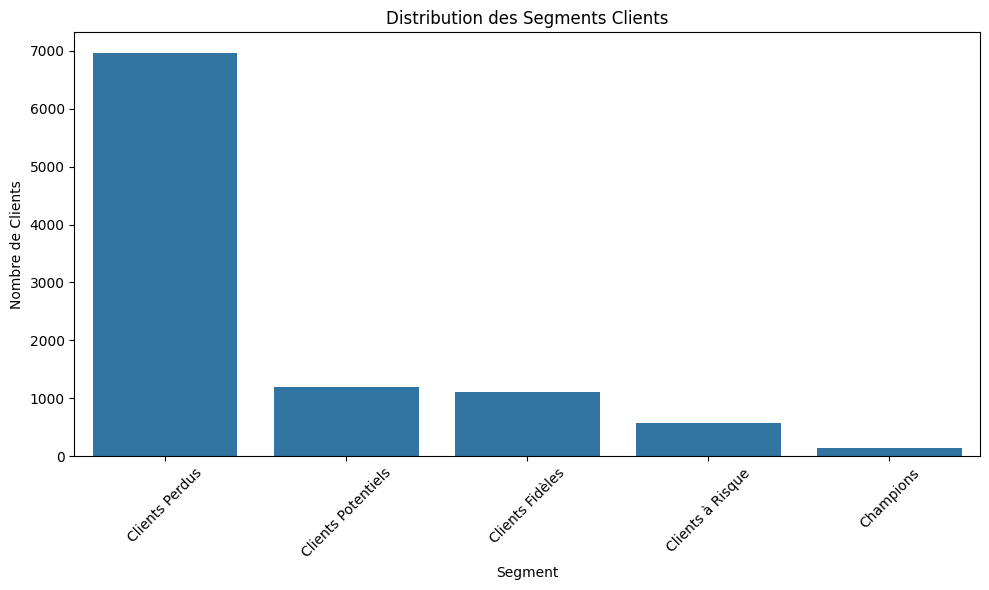

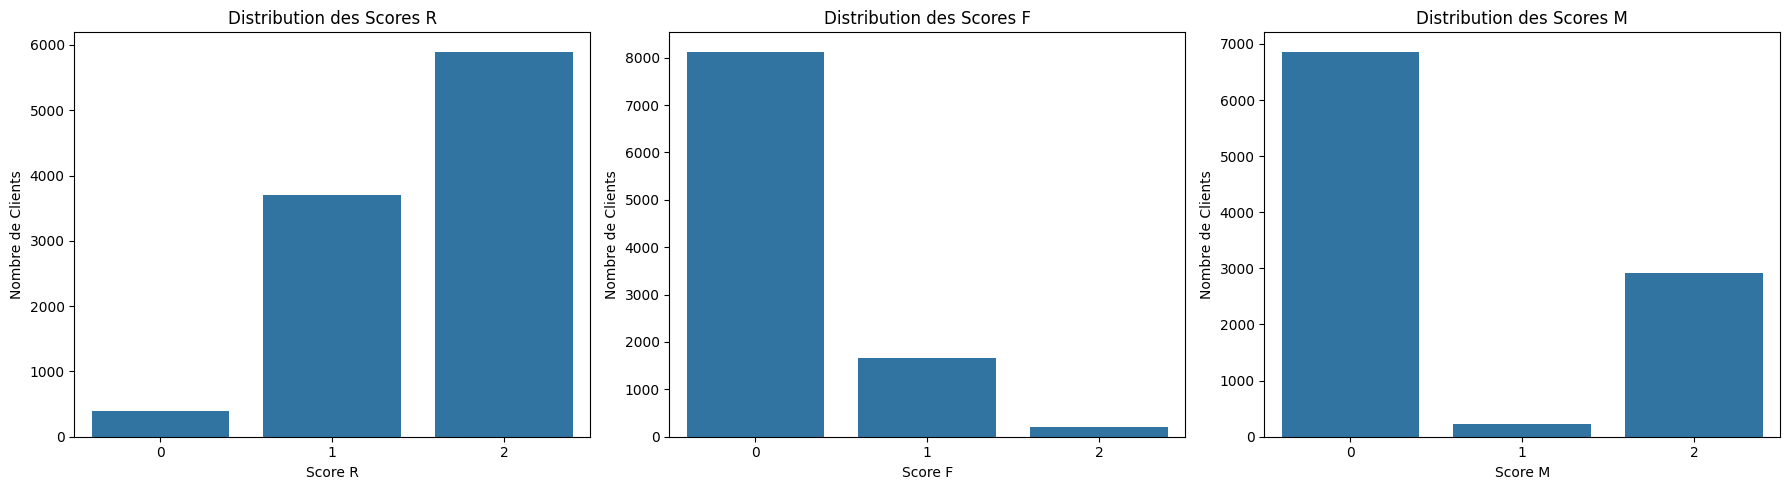


Caractéristiques moyennes par segment:


,months_since_last_event,total_purchases,total_spent,R_score,F_score,M_score,RFM_score,count
segment,,,,,,,,
Champions,-0.34,22.50,6693.18,2.00,2.00,2.00,6.00,145
Clients Fidèles,-0.21,4.77,1466.50,1.94,1.06,2.00,5.00,1116
Clients Potentiels,0.97,2.22,685.20,1.55,0.47,1.98,4.00,1189
Clients à Risque,2.23,1.20,323.48,1.16,0.11,1.74,3.00,578
Clients Perdus,1.18,0.03,3.17,1.51,0.00,0.02,1.53,6972




Exécution du modèle RFM #2: RFM avec récence fine

RFM Analysis Completed
Total clients segmentés: 10000

Distribution des scores R:
R_score
0      19
1    2838
2    2233
3    4910
Name: count, dtype: int64

Distribution des scores F:
F_score
0    8129
1    1656
2     215
Name: count, dtype: int64

Distribution des scores M:
M_score
0    6863
1     219
2    2918
Name: count, dtype: int64

Distribution des segments RFM:
RFM_segment
300    3177
100    2040
200    1619
312     912
302     550
112     376
102     332
212     329
202     202
301     121
322     121
122      47
222      47
101      40
201      31
311      22
000      17
310       7
211       3
111       2
210       2
012       2
110       1
Name: count, dtype: int64

--- CRITÈRES RFM UTILISÉS ---

RÉCENCE (months_since_last_event):
Score 3: moins de 0.5
Score 2: entre 0.5 et 2
Score 1: entre 2 et 6
Score 0: plus de 6

FRÉQUENCE (total_purchases):
Score 0: moins de 2
Score 1: entre 2 et 10
Score 2: plus de 10

MONTANT (tota

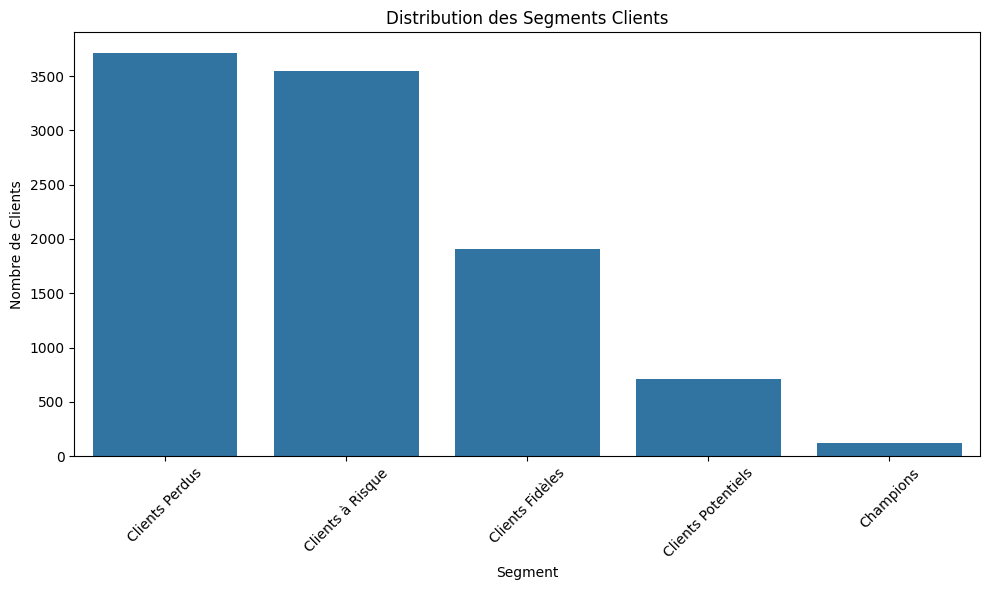

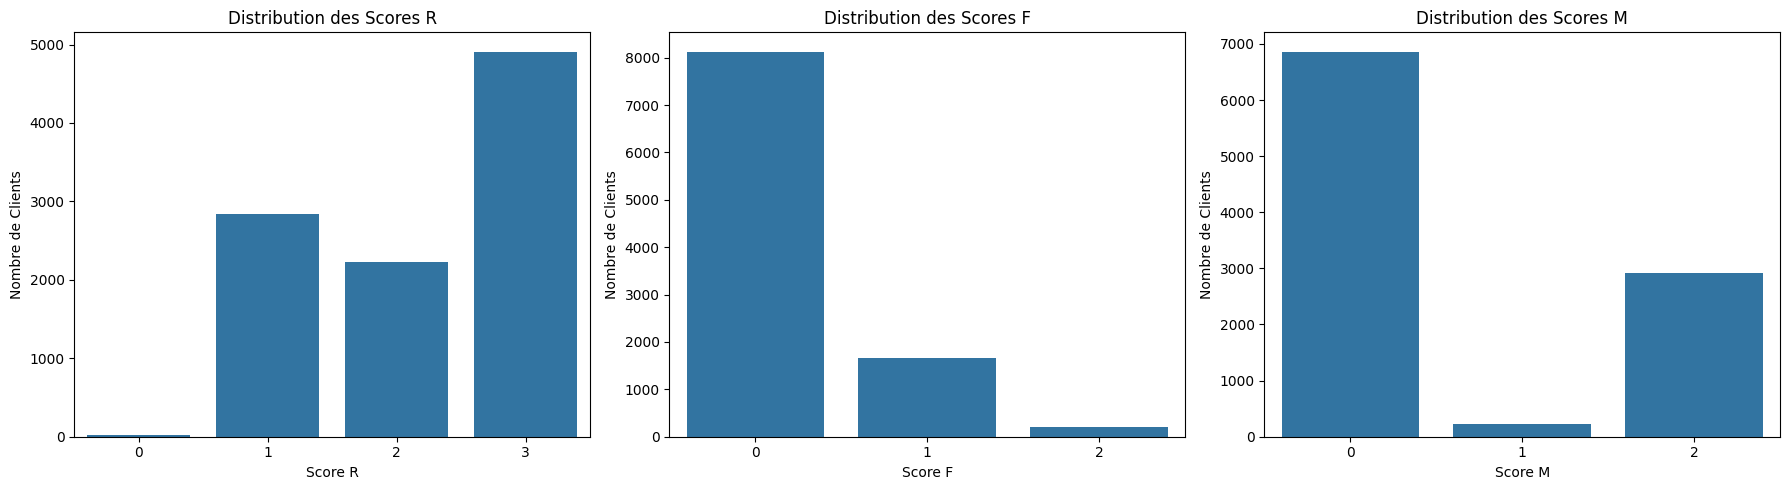


Caractéristiques moyennes par segment:


,months_since_last_event,total_purchases,total_spent,R_score,F_score,M_score,RFM_score,count
segment,,,,,,,,
Champions,-0.54,21.71,6383.90,3.00,2.00,2.00,7.00,121
Clients Fidèles,-0.12,3.86,1182.98,2.75,0.76,1.99,5.50,1907
Clients Potentiels,2.10,2.30,695.40,1.65,0.54,1.81,4.00,709
Clients à Risque,-0.09,0.12,30.44,2.80,0.00,0.20,3.00,3546
Clients Perdus,2.54,0.02,0.40,1.43,0.00,0.01,1.44,3717




Exécution du modèle RFM #3: RFM avec fréquence fine

RFM Analysis Completed
Total clients segmentés: 10000

Distribution des scores R:
R_score
0     399
1    3702
2    5899
Name: count, dtype: int64

Distribution des scores F:
F_score
0    6776
1    2021
2     988
3     215
Name: count, dtype: int64

Distribution des scores M:
M_score
0    6863
1     219
2    2918
Name: count, dtype: int64

Distribution des segments RFM:
RFM_segment
200    3834
100    2661
212    1043
222     651
112     602
122     301
000     281
211     147
232     145
012      81
210      70
132      64
111      56
022      25
110      16
221       8
011       6
032       6
121       2
220       1
Name: count, dtype: int64

--- CRITÈRES RFM UTILISÉS ---

RÉCENCE (months_since_last_event):
Score 2: moins de 1
Score 1: entre 1 et 5
Score 0: plus de 5

FRÉQUENCE (total_purchases):
Score 0: moins de 1
Score 1: entre 1 et 3
Score 2: entre 3 et 10
Score 3: plus de 10

MONTANT (total_spent):
Score 0: moins de 20€
Score 

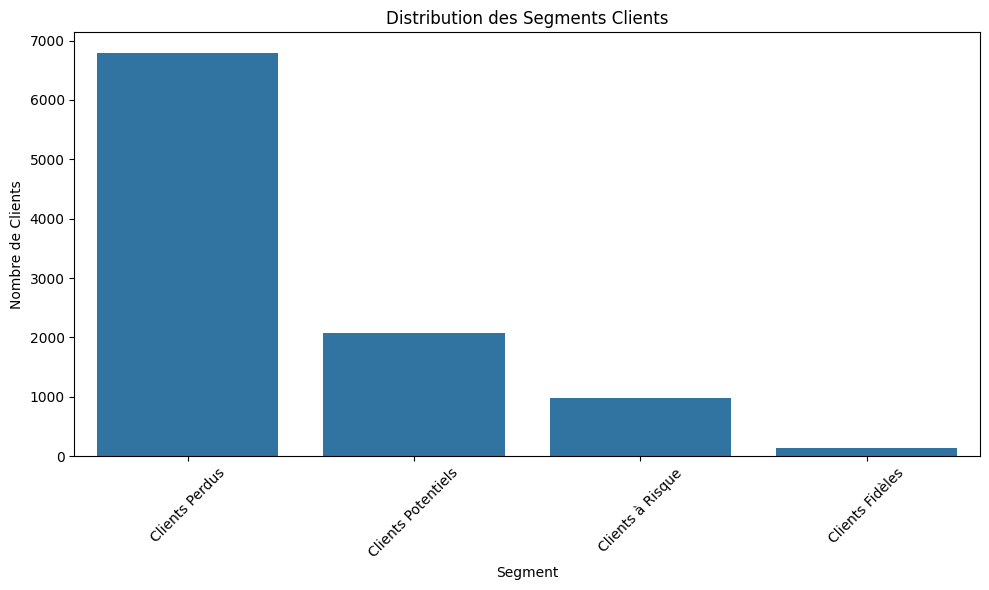

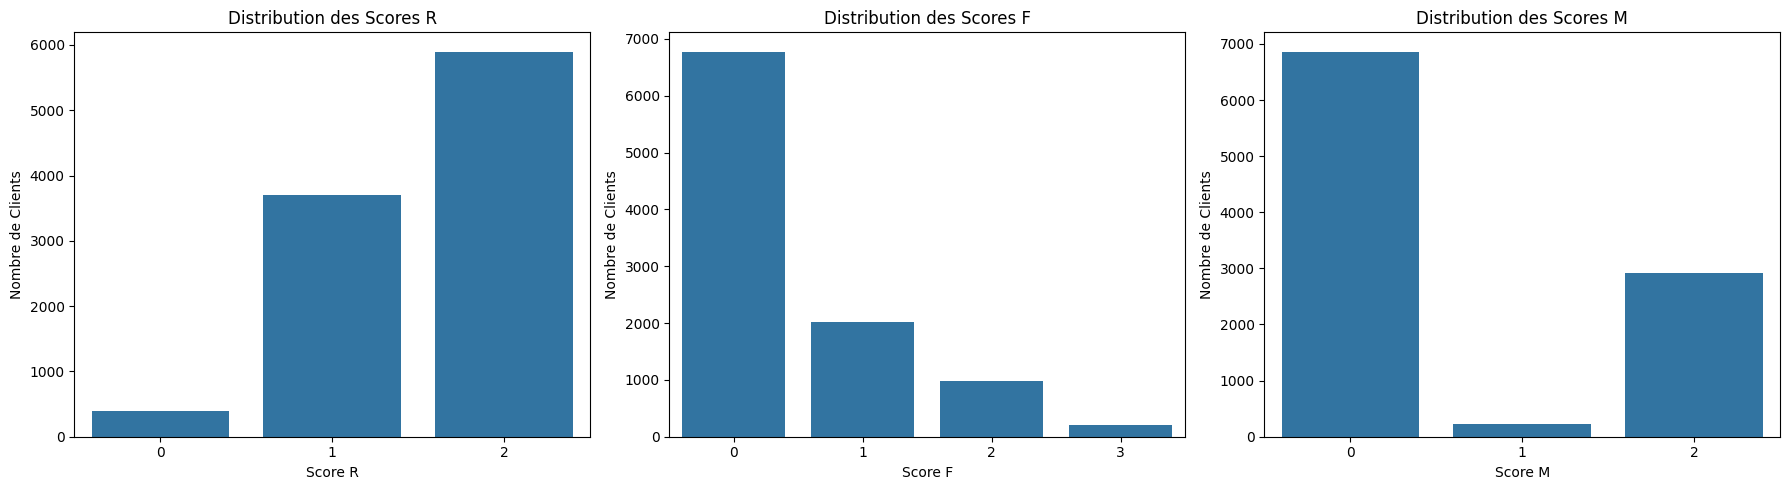


Caractéristiques moyennes par segment:


,months_since_last_event,total_purchases,total_spent,R_score,F_score,M_score,RFM_score,count
segment,,,,,,,,
Clients Fidèles,-0.34,22.50,6693.18,2.00,3.00,2.00,7.00,145
Clients Potentiels,0.17,3.62,1123.86,1.82,1.53,2.00,5.34,2073
Clients à Risque,2.31,1.36,335.61,1.11,1.03,1.65,3.79,984
Clients Perdus,1.14,0.00,0.05,1.52,0.00,0.00,1.53,6798




Exécution du modèle RFM #4: RFM avec montant fin

RFM Analysis Completed
Total clients segmentés: 10000

Distribution des scores R:
R_score
0     399
1    3702
2    5899
Name: count, dtype: int64

Distribution des scores F:
F_score
0    8129
1    1656
2     215
Name: count, dtype: int64

Distribution des scores M:
M_score
0    6808
1     135
2     286
3    2771
Name: count, dtype: int64

Distribution des segments RFM:
RFM_segment
200    3860
100    2666
213    1024
203     569
113     506
103     354
000     281
202     159
223     145
201      83
102      64
123      64
003      55
013      48
212      44
101      30
211      14
112      14
023       6
002       4
001       4
111       4
012       1
210       1
Name: count, dtype: int64

--- CRITÈRES RFM UTILISÉS ---

RÉCENCE (months_since_last_event):
Score 2: moins de 1
Score 1: entre 1 et 5
Score 0: plus de 5

FRÉQUENCE (total_purchases):
Score 0: moins de 2
Score 1: entre 2 et 10
Score 2: plus de 10

MONTANT (total_spent):
Score

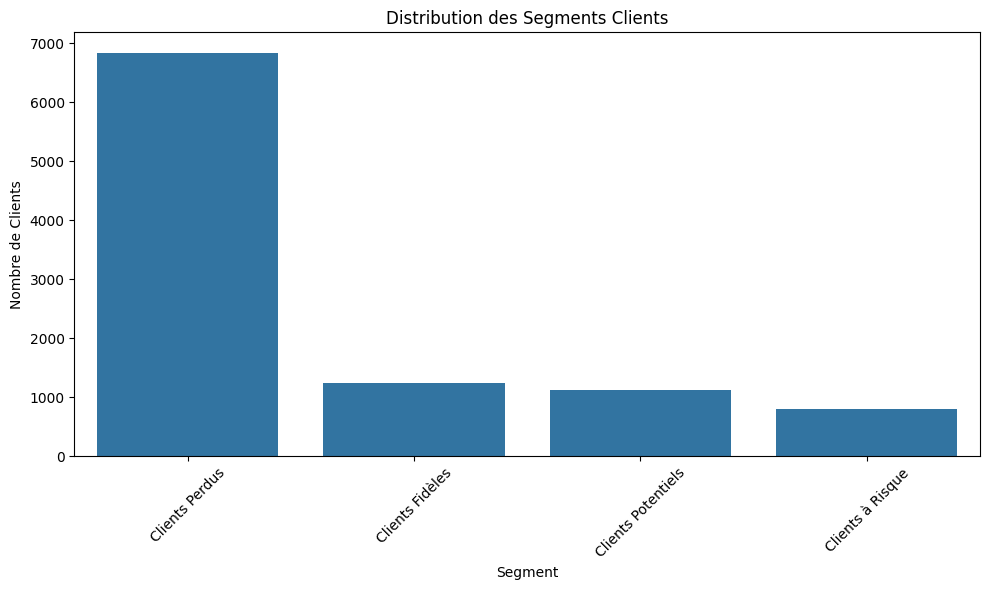

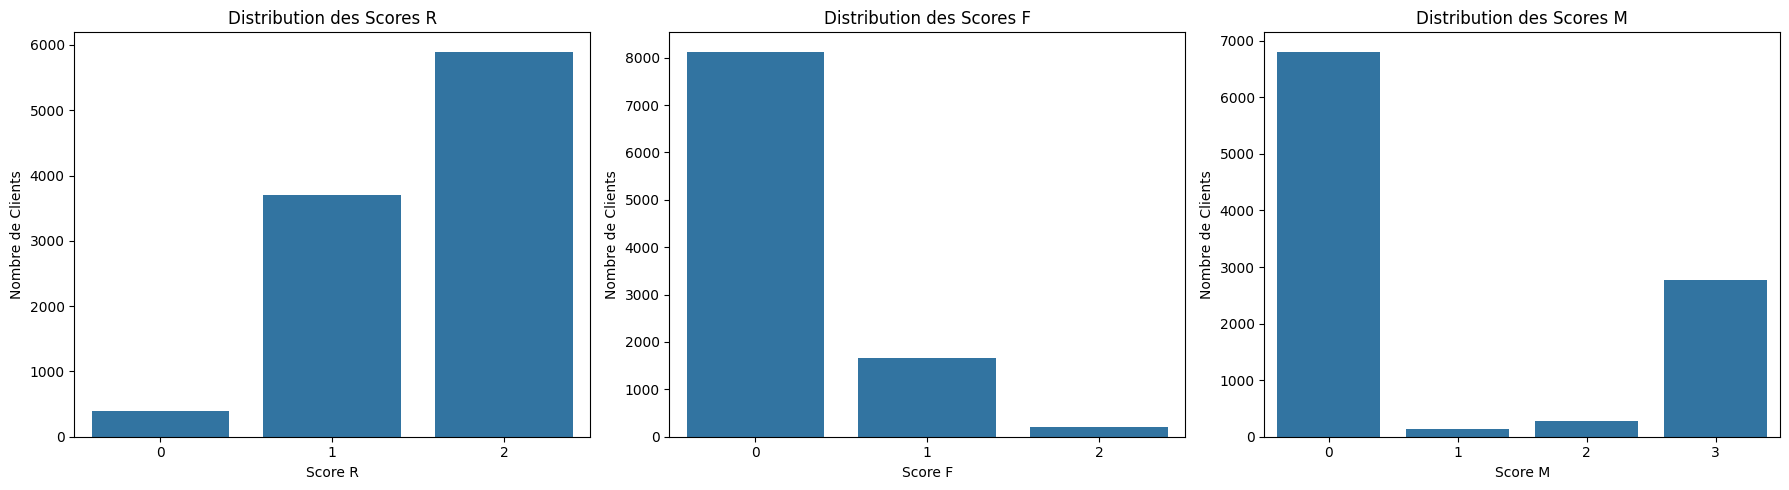


Caractéristiques moyennes par segment:


,months_since_last_event,total_purchases,total_spent,R_score,F_score,M_score,RFM_score,count
segment,,,,,,,,
Clients Fidèles,-0.22,6.91,2113.01,1.95,1.17,3.00,6.12,1233
Clients Potentiels,1.02,2.30,720.95,1.54,0.50,2.96,5.00,1125
Clients à Risque,2.08,1.19,267.62,1.19,0.10,2.44,3.74,797
Clients Perdus,1.14,0.01,0.17,1.52,0.00,0.01,1.53,6845




Exécution du modèle RFM #5: RFM complet

RFM Analysis Completed
Total clients segmentés: 10000

Distribution des scores R:
R_score
0      19
1    2838
2    2233
3    4910
Name: count, dtype: int64

Distribution des scores F:
F_score
0    6776
1    2021
2     988
3     215
Name: count, dtype: int64

Distribution des scores M:
M_score
0    6808
1     135
2     286
3    2771
Name: count, dtype: int64

Distribution des segments RFM:
RFM_segment
300    3119
100    2031
200    1609
313     807
323     564
113     459
213     321
123     213
223     190
312     173
333     121
311      88
112      58
133      47
233      47
212      41
111      26
310      23
000      17
211      15
322      10
210       7
321       5
222       3
110       2
121       1
122       1
023       1
013       1
Name: count, dtype: int64

--- CRITÈRES RFM UTILISÉS ---

RÉCENCE (months_since_last_event):
Score 3: moins de 0.5
Score 2: entre 0.5 et 2
Score 1: entre 2 et 6
Score 0: plus de 6

FRÉQUENCE (total_purchas

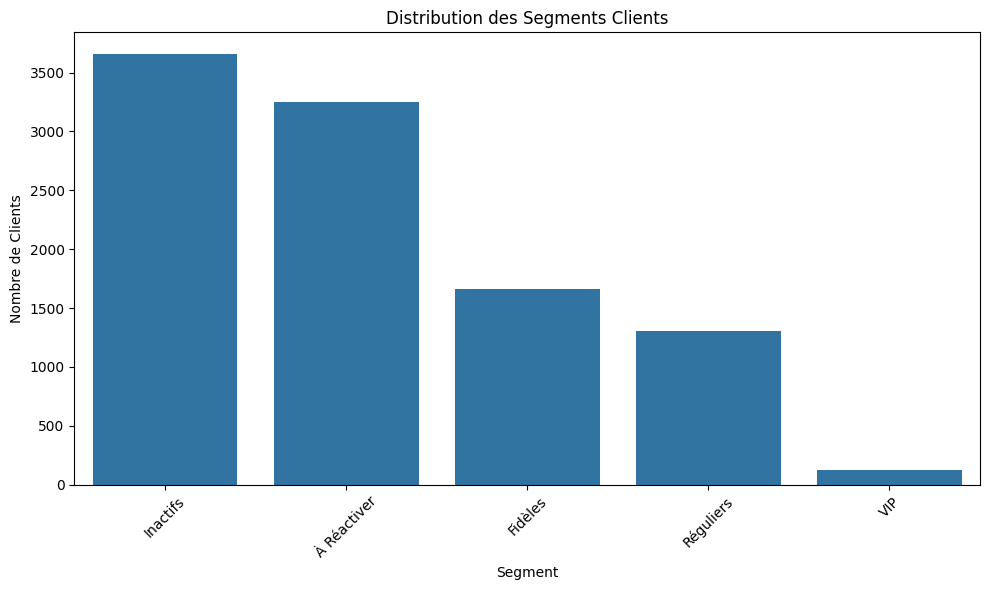

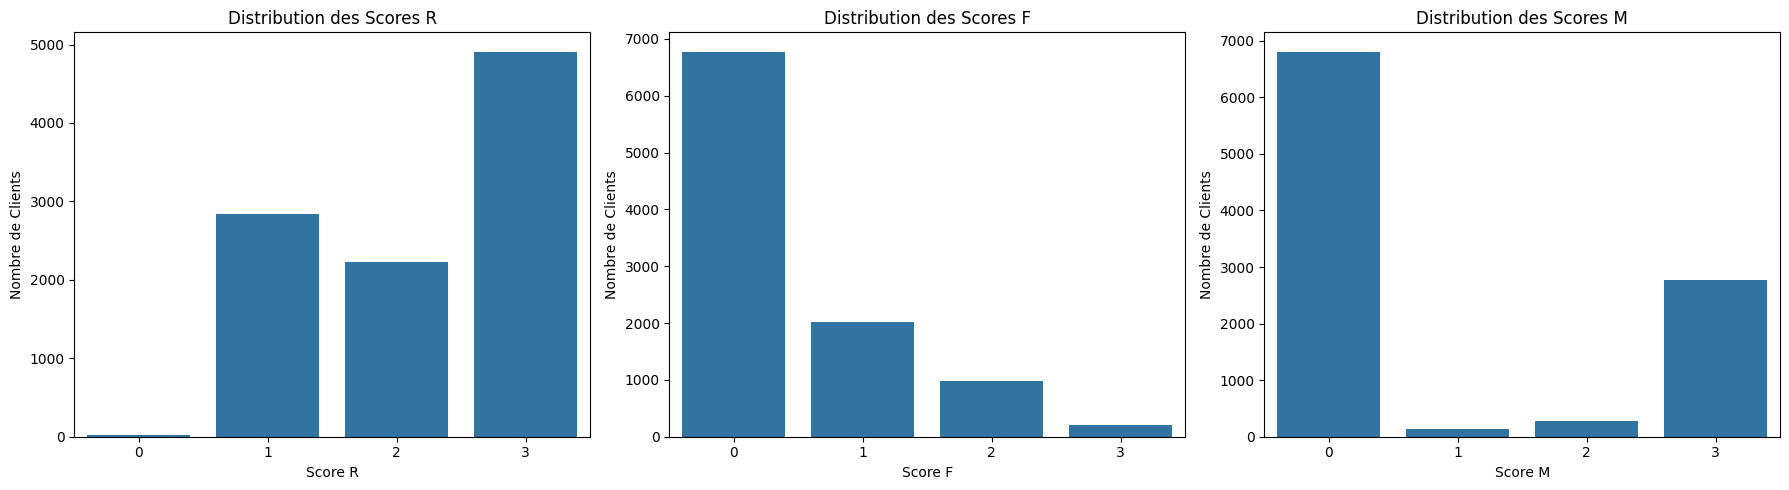


Caractéristiques moyennes par segment:


,months_since_last_event,total_purchases,total_spent,R_score,F_score,M_score,RFM_score,count
segment,,,,,,,,
VIP,-0.54,21.71,6383.90,3.00,3.00,3.00,9.00,121
Fidèles,-0.19,4.17,1297.25,2.80,1.57,2.99,7.37,1665
Réguliers,2.07,1.84,531.86,1.69,1.17,2.69,5.55,1305
À Réactiver,-0.38,0.05,1.35,2.94,0.04,0.05,3.03,3250
Inactifs,2.53,0.00,0.00,1.44,0.00,0.00,1.44,3659




Récapitulatif des modèles RFM générés:
1. RFM Base:
   - Nombre de segments distincts: 5
   - Segment le plus représenté: 'Clients Perdus' (6972 clients, 69.7%)
   - Dimensions: R [3 niveaux], F [3 niveaux], M [3 niveaux]

2. RFM avec récence fine:
   - Nombre de segments distincts: 5
   - Segment le plus représenté: 'Clients Perdus' (3717 clients, 37.2%)
   - Dimensions: R [4 niveaux], F [3 niveaux], M [3 niveaux]

3. RFM avec fréquence fine:
   - Nombre de segments distincts: 4
   - Segment le plus représenté: 'Clients Perdus' (6798 clients, 68.0%)
   - Dimensions: R [3 niveaux], F [4 niveaux], M [3 niveaux]

4. RFM avec montant fin:
   - Nombre de segments distincts: 4
   - Segment le plus représenté: 'Clients Perdus' (6845 clients, 68.5%)
   - Dimensions: R [3 niveaux], F [3 niveaux], M [4 niveaux]

5. RFM complet:
   - Nombre de segments distincts: 5
   - Segment le plus représenté: 'Inactifs' (3659 clients, 36.6%)
   - Dimensions: R [4 niveaux], F [4 niveaux], M [4 niveaux]



In [31]:
# Liste pour stocker les différents résultats de segmentation RFM
rfm_segments_list = []

# Définir 5 combinaisons d'hyperparamètres différents
hyperparameter_sets = [
    {
        # Jeu 1: Paramètres de base (les mêmes que dans votre exemple)
        "name": "RFM Base",
        "r_thresholds": [1, 5],
        "r_scores": [2, 1, 0],
        "f_thresholds": [2, 10],
        "f_scores": [0, 1, 2],
        "m_thresholds": [20, 50],
        "m_scores": [0, 1, 2],
        "segment_thresholds": [0, 3, 4, 5, 6],
        "segment_names": ['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']
    },
    {
        # Jeu 2: Plus de granularité dans la récence
        "name": "RFM avec récence fine",
        "r_thresholds": [0.5, 2, 6],
        "r_scores": [3, 2, 1, 0],
        "f_thresholds": [2, 10],
        "f_scores": [0, 1, 2],
        "m_thresholds": [20, 50],
        "m_scores": [0, 1, 2],
        "segment_thresholds": [0, 3, 4, 5, 7],
        "segment_names": ['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']
    },
    {
        # Jeu 3: Plus de granularité dans la fréquence
        "name": "RFM avec fréquence fine",
        "r_thresholds": [1, 5],
        "r_scores": [2, 1, 0],
        "f_thresholds": [1, 3, 10],
        "f_scores": [0, 1, 2, 3],
        "m_thresholds": [20, 50],
        "m_scores": [0, 1, 2],
        "segment_thresholds": [0, 3, 5, 7, 8],
        "segment_names": ['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']
    },
    {
        # Jeu 4: Plus de granularité dans le montant
        "name": "RFM avec montant fin",
        "r_thresholds": [1, 5],
        "r_scores": [2, 1, 0],
        "f_thresholds": [2, 10],
        "f_scores": [0, 1, 2],
        "m_thresholds": [10, 30, 75],
        "m_scores": [0, 1, 2, 3],
        "segment_thresholds": [0, 3, 5, 6, 8],
        "segment_names": ['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']
    },
    {
        # Jeu 5: Ensemble complet avec granularité sur toutes les dimensions
        "name": "RFM complet",
        "r_thresholds": [0.5, 2, 6],
        "r_scores": [3, 2, 1, 0],
        "f_thresholds": [1, 3, 10],
        "f_scores": [0, 1, 2, 3],
        "m_thresholds": [10, 30, 75],
        "m_scores": [0, 1, 2, 3],
        "segment_thresholds": [0, 3, 5, 7, 9],
        "segment_names": ['Inactifs', 'À Réactiver', 'Réguliers', 'Fidèles', 'VIP']
    }
]

# Exécuter l'analyse RFM pour chaque jeu d'hyperparamètres
for i, params in enumerate(hyperparameter_sets):
    print(f"\n\n{'='*50}")
    print(f"Exécution du modèle RFM #{i+1}: {params['name']}")
    print(f"{'='*50}\n")
    
    # Exécuter l'analyse avec les hyperparamètres spécifiés
    result_df = perform_rfm_analysis(
        user_segments_df_tmspt,
        r_column='months_since_last_event',
        r_thresholds=params['r_thresholds'],
        r_scores=params['r_scores'],
        f_column='total_purchases',
        f_thresholds=params['f_thresholds'],
        f_scores=params['f_scores'],
        m_column='total_spent',
        m_thresholds=params['m_thresholds'],
        m_scores=params['m_scores'],
        segment_thresholds=params['segment_thresholds'],
        segment_names=params['segment_names'],
        visualize=True  # Vous pouvez changer à False si vous ne voulez pas les graphiques pour chaque itération
    )
    
    # Stocker le résultat dans la liste avec des métadonnées
    rfm_segments_list.append({
        "name": params["name"],
        "params": params,
        "result": result_df
    })

# Afficher un récapitulatif des différents modèles
print("\n\nRécapitulatif des modèles RFM générés:")
print("=" * 80)
for i, model in enumerate(rfm_segments_list):
    n_segments = model["result"]["segment"].nunique()
    top_segment = model["result"]["segment"].value_counts().index[0]
    top_segment_count = model["result"]["segment"].value_counts().iloc[0]
    top_segment_pct = (top_segment_count / len(model["result"])) * 100
    
    print(f"{i+1}. {model['name']}:")
    print(f"   - Nombre de segments distincts: {n_segments}")
    print(f"   - Segment le plus représenté: '{top_segment}' ({top_segment_count} clients, {top_segment_pct:.1f}%)")
    print(f"   - Dimensions: R [{len(model['params']['r_scores'])} niveaux], " +
          f"F [{len(model['params']['f_scores'])} niveaux], " +
          f"M [{len(model['params']['m_scores'])} niveaux]")
    print()

# Pour accéder ultérieurement à un modèle spécifique:
# model_3 = rfm_segments_list[2]["result"]

In [32]:
rfm_segments_list

[{'name': 'RFM Base',
  'params': {'name': 'RFM Base',
   'r_thresholds': [1, 5],
   'r_scores': [2, 1, 0],
   'f_thresholds': [2, 10],
   'f_scores': [0, 1, 2],
   'm_thresholds': [20, 50],
   'm_scores': [0, 1, 2],
   'segment_thresholds': [0, 3, 4, 5, 6],
   'segment_names': ['Clients Perdus',
    'Clients à Risque',
    'Clients Potentiels',
    'Clients Fidèles',
    'Champions']},
  'result':         user_id  total_events  total_views  total_purchases  \
  0     621666961            25         25.0              0.0   
  1     575336124            48         48.0              0.0   
  2     557550064            16         16.0              0.0   
  3     513601305            64         61.0              2.0   
  4     612100896           146        137.0              1.0   
  ...         ...           ...          ...              ...   
  9995  532087235            35         22.0              4.0   
  9996  523298443            34         34.0              0.0   
  9997  5291199

--------------------------------------------------------------
-------- MODEL ----------  RFM Base
-------- PARAMS ----------  {'name': 'RFM Base', 'r_thresholds': [1, 5], 'r_scores': [2, 1, 0], 'f_thresholds': [2, 10], 'f_scores': [0, 1, 2], 'm_thresholds': [20, 50], 'm_scores': [0, 1, 2], 'segment_thresholds': [0, 3, 4, 5, 6], 'segment_names': ['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']}
Silhouette Coefficient
0.5913934821471017
Calinski–Harabasz Index
50831.889698749714
Davies–Bouldin Index
0.4922637845485518


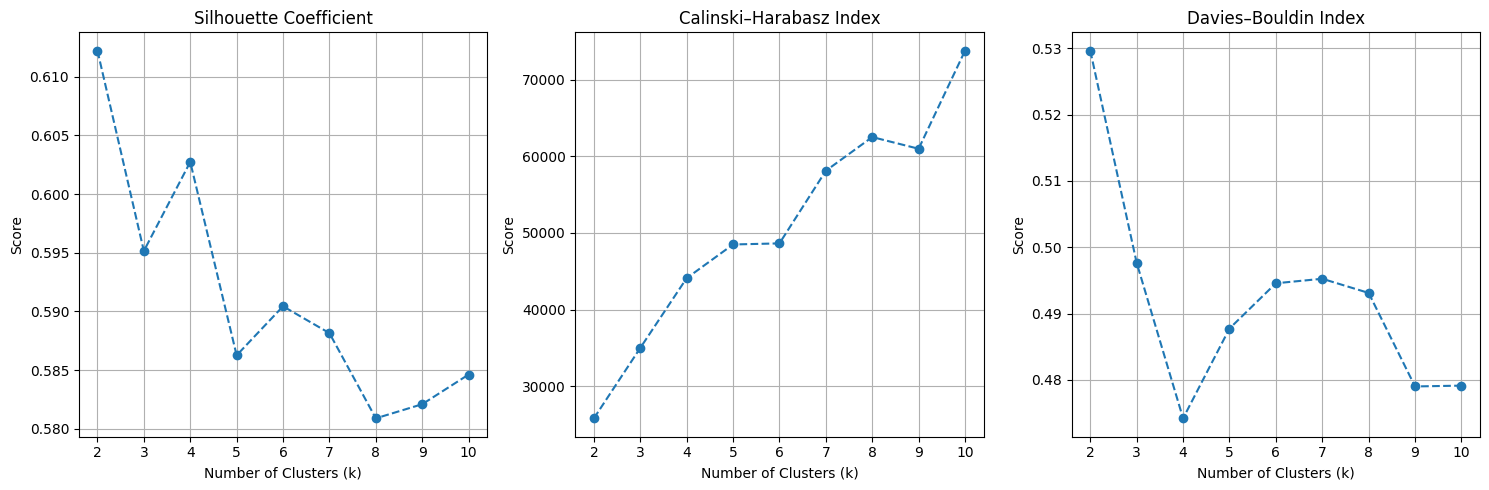

--------------------------------------------------------------
-------- MODEL ----------  RFM avec récence fine
-------- PARAMS ----------  {'name': 'RFM avec récence fine', 'r_thresholds': [0.5, 2, 6], 'r_scores': [3, 2, 1, 0], 'f_thresholds': [2, 10], 'f_scores': [0, 1, 2], 'm_thresholds': [20, 50], 'm_scores': [0, 1, 2], 'segment_thresholds': [0, 3, 4, 5, 7], 'segment_names': ['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']}
Silhouette Coefficient
0.5913934821470428
Calinski–Harabasz Index
50831.88969874884
Davies–Bouldin Index
0.4922637845486094


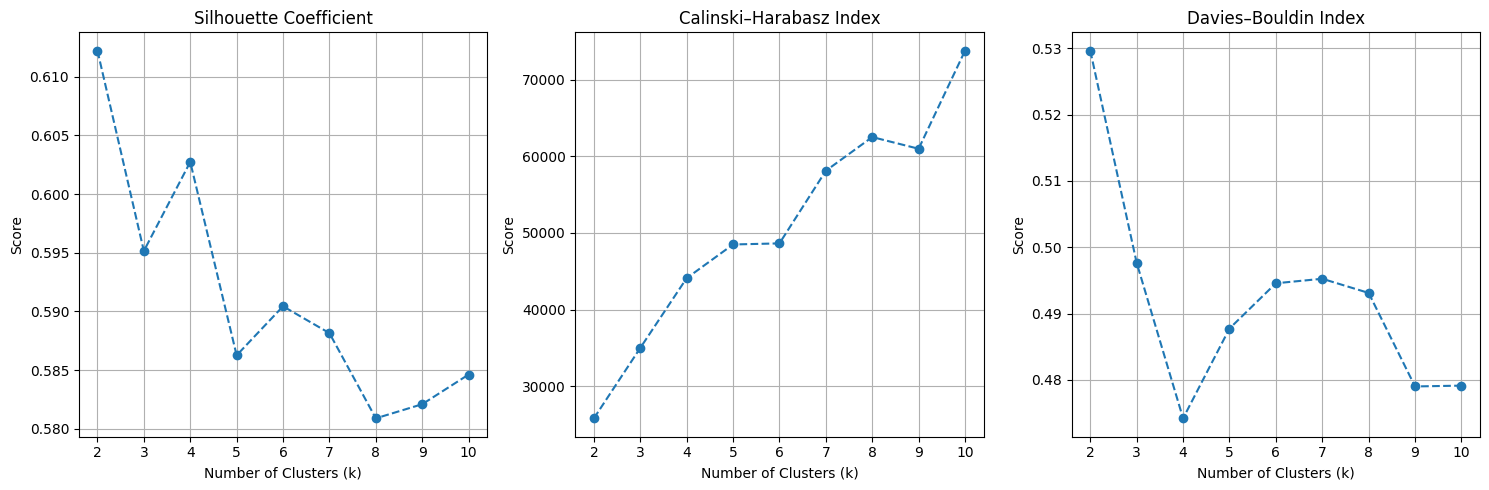

--------------------------------------------------------------
-------- MODEL ----------  RFM avec fréquence fine
-------- PARAMS ----------  {'name': 'RFM avec fréquence fine', 'r_thresholds': [1, 5], 'r_scores': [2, 1, 0], 'f_thresholds': [1, 3, 10], 'f_scores': [0, 1, 2, 3], 'm_thresholds': [20, 50], 'm_scores': [0, 1, 2], 'segment_thresholds': [0, 3, 5, 7, 8], 'segment_names': ['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']}
Silhouette Coefficient
0.5913934821470459
Calinski–Harabasz Index
50831.88969874818
Davies–Bouldin Index
0.49226378454858594


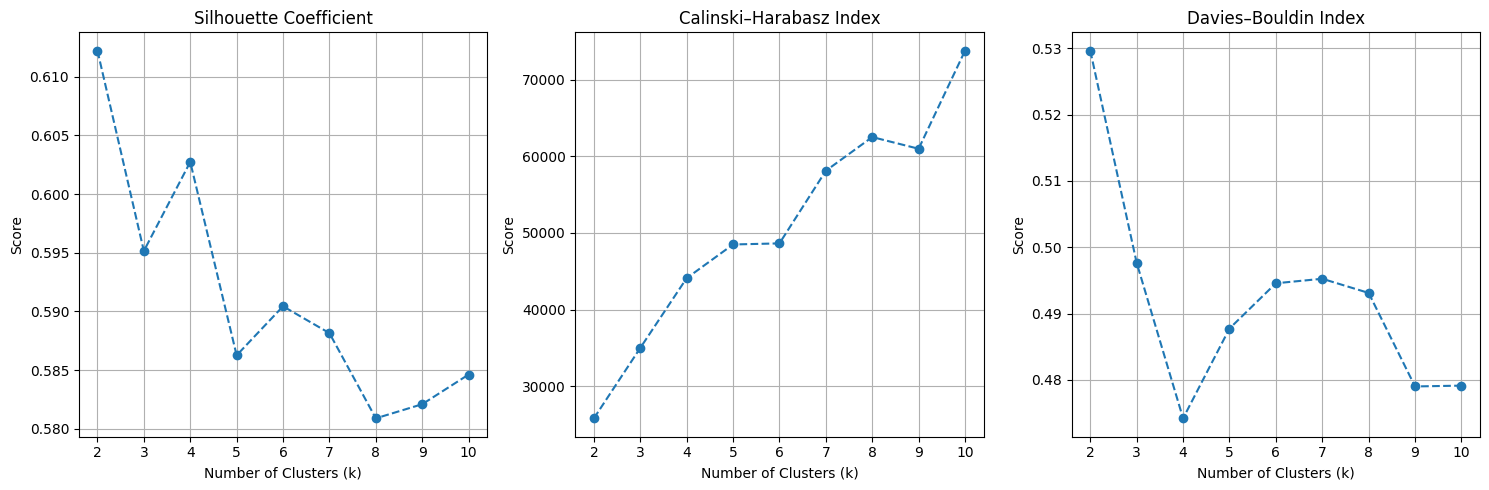

--------------------------------------------------------------
-------- MODEL ----------  RFM avec montant fin
-------- PARAMS ----------  {'name': 'RFM avec montant fin', 'r_thresholds': [1, 5], 'r_scores': [2, 1, 0], 'f_thresholds': [2, 10], 'f_scores': [0, 1, 2], 'm_thresholds': [10, 30, 75], 'm_scores': [0, 1, 2, 3], 'segment_thresholds': [0, 3, 5, 6, 8], 'segment_names': ['Clients Perdus', 'Clients à Risque', 'Clients Potentiels', 'Clients Fidèles', 'Champions']}
Silhouette Coefficient
0.59139348214702
Calinski–Harabasz Index
50831.889698747225
Davies–Bouldin Index
0.4922637845486357


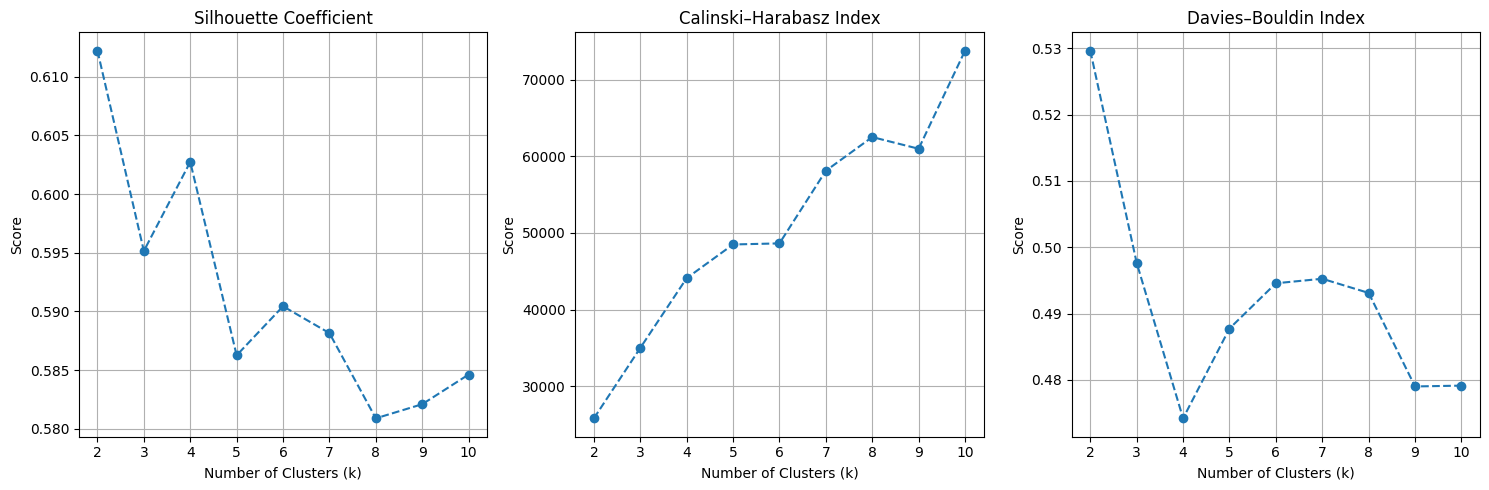

--------------------------------------------------------------
-------- MODEL ----------  RFM complet
-------- PARAMS ----------  {'name': 'RFM complet', 'r_thresholds': [0.5, 2, 6], 'r_scores': [3, 2, 1, 0], 'f_thresholds': [1, 3, 10], 'f_scores': [0, 1, 2, 3], 'm_thresholds': [10, 30, 75], 'm_scores': [0, 1, 2, 3], 'segment_thresholds': [0, 3, 5, 7, 9], 'segment_names': ['Inactifs', 'À Réactiver', 'Réguliers', 'Fidèles', 'VIP']}
Silhouette Coefficient
0.5913934821469571
Calinski–Harabasz Index
50831.88969874443
Davies–Bouldin Index
0.4922637845487156


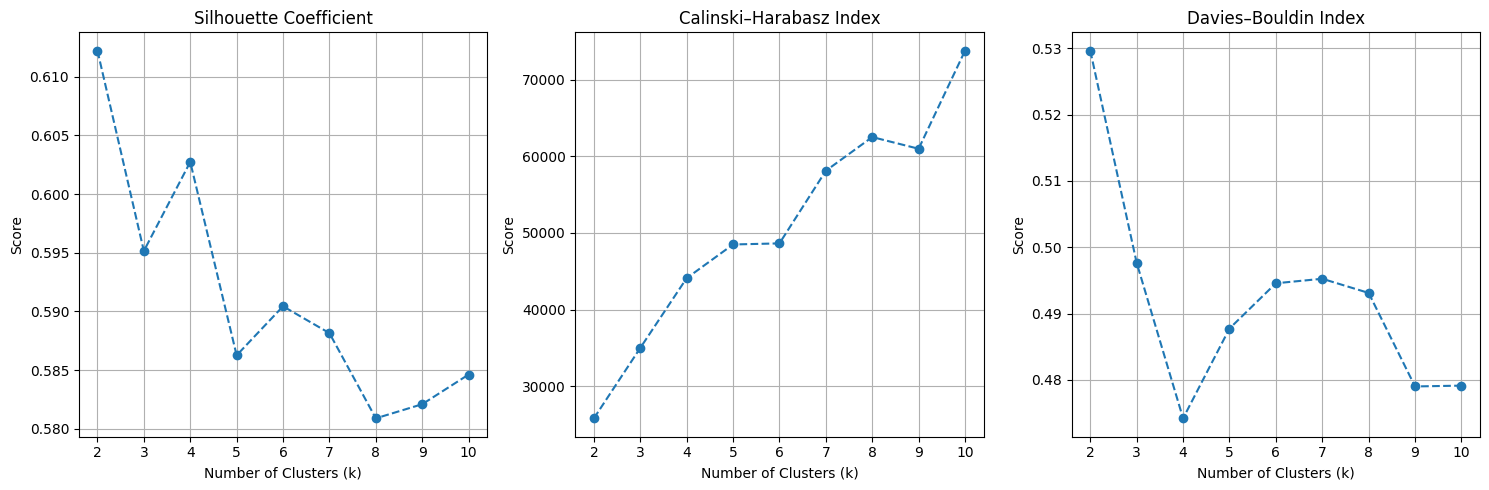

In [33]:
for model in rfm_segments_list:
    params = model['params']
    result_df = model['result']
    
    # Define the range of clusters to evaluate
    ks = range(2, 11)

    # Initialize lists to store the scores
    silhouette_scores = []
    calinski_harabasz_scores = []
    davies_bouldin_scores = []

    # Prepare the data - drop columns that shouldn't be used for clustering
    X_model = result_df.drop(columns=["segment", "last_event_time", "RFM_segment"])

    # Evaluate clustering for each k
    for k in ks:
        km2 = KMeans(n_clusters=k, random_state=42).fit(X_model)
        labels = km2.labels_
        
        # Compute the metrics
        silhouette_scores.append(silhouette_score(X_model, labels))
        calinski_harabasz_scores.append(calinski_harabasz_score(X_model, labels))
        davies_bouldin_scores.append(davies_bouldin_score(X_model, labels))
    
    print("--------------------------------------------------------------")
    print(f"-------- MODEL ----------  {model['name']}")
    print(f"-------- PARAMS ----------  {model['params']}")
    # Plot the metrics
    plt.figure(figsize=(15, 5))
    print("Silhouette Coefficient")
    print(np.mean(silhouette_scores))

    # Silhouette Coefficient
    plt.subplot(1, 3, 1)
    plt.plot(ks, silhouette_scores, marker='o', linestyle='--')
    plt.title("Silhouette Coefficient")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Score")
    plt.grid(True)
    print("Calinski–Harabasz Index")
    print(np.mean(calinski_harabasz_scores))

    # Calinski–Harabasz Index
    plt.subplot(1, 3, 2)
    plt.plot(ks, calinski_harabasz_scores, marker='o', linestyle='--')
    plt.title("Calinski–Harabasz Index")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Score")
    plt.grid(True)
    print("Davies–Bouldin Index")
    print(np.mean(davies_bouldin_scores))

    # Davies–Bouldin Index
    plt.subplot(1, 3, 3)
    plt.plot(ks, davies_bouldin_scores, marker='o', linestyle='--')
    plt.title("Davies–Bouldin Index")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Score")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

## Stratified K Fold

In [34]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


In [35]:
import pytest
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

def test_clustering_with_stratified_kfold():
    """
    Test clustering performance using StratifiedKFold cross-validation.
    
    For clustering (unsupervised learning), we need to:
    1. First perform clustering on the entire dataset
    2. Use the resulting labels as a "pseudo-target" for stratification
    3. Evaluate how consistent the clustering is across folds
    """
    # Load or create sample data (replace with actual data loading)
    # This is a simplified example - you'll need to adapt to your actual dataframe
    try:
        df = pd.read_csv('path_to_your_data.csv')  # Replace with your data loading
        X = df.drop(columns=["last_event_time"])  # Adjust columns as needed
    except:
        # Create dummy data for testing if file not found
        X = pd.DataFrame(np.random.rand(100, 5), 
                        columns=['total_purchases', 'total_spent', 'avg_basket', 
                                'days_since_last_event', 'avg_time_between_events'])
    
    # 1. First perform clustering on entire dataset to get "pseudo-labels"
    # Choose K based on your prior analysis
    k = 5  # Replace with your optimal K value
    kmeans = KMeans(n_clusters=k, random_state=42)
    pseudo_labels = kmeans.fit_predict(X)
    
    # 2. Use StratifiedKFold with these pseudo-labels
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Track metrics across folds
    silhouette_scores = []
    calinski_scores = []
    davies_bouldin_scores = []
    
    # 3. Cross-validate
    for train_idx, test_idx in skf.split(X, pseudo_labels):
        # Split data
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        
        # Scale features (recommended for KMeans)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train on fold
        fold_kmeans = KMeans(n_clusters=k, random_state=42)
        fold_kmeans.fit(X_train_scaled)
        
        # Predict on test set
        test_labels = fold_kmeans.predict(X_test_scaled)
        
        # Only calculate metrics if we have at least 2 clusters in test set
        unique_labels = np.unique(test_labels)
        if len(unique_labels) >= 2:
            # Calculate metrics
            silhouette_scores.append(silhouette_score(X_test_scaled, test_labels))
            calinski_scores.append(calinski_harabasz_score(X_test_scaled, test_labels))
            davies_bouldin_scores.append(davies_bouldin_score(X_test_scaled, test_labels))
    
    # 4. Assert that metrics are consistent and within expected range
    assert len(silhouette_scores) > 0, "No valid silhouette scores calculated"
    avg_silhouette = np.mean(silhouette_scores)
    avg_calinski = np.mean(calinski_scores)
    avg_davies_bouldin = np.mean(davies_bouldin_scores)
    
    # Print results for inspection
    print(f"Cross-validated metrics over {len(silhouette_scores)} folds:")
    print(f"Average Silhouette Score: {avg_silhouette:.4f}")
    print(f"Average Calinski-Harabasz Score: {avg_calinski:.4f}")
    print(f"Average Davies-Bouldin Score: {avg_davies_bouldin:.4f}")
    
    # Check if metrics are within reasonable range
    assert -1 <= avg_silhouette <= 1, f"Silhouette score {avg_silhouette} outside valid range [-1,1]"
    assert avg_calinski > 0, f"Calinski-Harabasz score {avg_calinski} should be positive"
    assert avg_davies_bouldin > 0, f"Davies-Bouldin score {avg_davies_bouldin} should be positive"

In [36]:
con.close()